# Homework #1 (Due 09/02/2026, 11:59pm)

**ELEC70122: ML for Safety Critical Decision-Making**<br>
**Instructor: Sonali Parbhoo**<br>
**Fall 2026**

**Name:**


### Instructions:

**Submission Format:** Use this notebook as a template to complete your homework. Please intersperse text blocks (using Markdown cells) amongst `python` code and results -- format your submission for maximum readability. Your assignments will be graded for correctness as well as clarity of exposition and presentation -- a “right” answer by itself without an explanation or is presented with a difficult to follow format will receive no credit.

**Code Check:** Before submitting, you must do a "Restart and Run All" under "Kernel" in the Jupyter or colab menu. ***Portions of your submission that contains syntactic or run-time errors will not be graded***.

**Libraries and packages:** Unless a problems specifically asks you to implement from scratch, you are welcomed to use any `python` library package in the standard Anaconda distribution.

In [2]:
### Import basic libraries
import numpy as np
import pandas as pd
import sklearn as sk
from scipy.stats import multivariate_normal
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def get_posterior_samples(prior_var, noise_var, x_matrix, y_matrix, x_test_matrix, samples=100):
    '''Function to generate posterior predictive samples for Bayesian linear regression model'''
    prior_variance = np.diag(prior_var * np.ones(x_matrix.shape[1]))
    prior_precision = np.linalg.inv(prior_variance)

    joint_precision = prior_precision + x_matrix.T.dot(x_matrix) / noise_var
    joint_variance = np.linalg.inv(joint_precision)
    joint_mean = joint_variance.dot(x_matrix.T.dot(y_matrix)) / noise_var

    #sampling 100 points from the posterior
    posterior_samples = np.random.multivariate_normal(joint_mean.flatten(), joint_variance, size=samples)

    #take posterior predictive samples
    posterior_predictions = np.dot(posterior_samples, x_test_matrix.T)
    posterior_predictive_samples = posterior_predictions[np.newaxis, :, :] + np.random.normal(0, noise_var**0.5, size=(100, posterior_predictions.shape[0], posterior_predictions.shape[1]))
    posterior_predictive_samples = posterior_predictive_samples.reshape((100 * posterior_predictions.shape[0], posterior_predictions.shape[1]))
    return posterior_predictions, posterior_predictive_samples


def generate_data(number_of_points=10, noise_variance=0.3):
    '''Function for generating toy regression data'''
    #training x
    x_train = np.hstack((np.linspace(-1, -0.5, number_of_points), np.linspace(0.5, 1, number_of_points)))
    #function relating x and y
    f = lambda x: 3 * x**3
    #y is equal to f(x) plus gaussian noise
    y_train = f(x_train) + np.random.normal(0, noise_variance**0.5, 2 * number_of_points)
    x_test = np.array(list(set(list(np.hstack((np.linspace(-1, 1, 200), x_train))))))
    x_test = np.sort(x_test)
    return x_train, y_train, x_test

## Part I: Maximum Likelihood Estimators for Polynomial Regression

In this problem, you are given a function, `generate_data`, to generate toy datasets with a single predictor $X$ representing patient age (normalized) and a single outcome $y$ representing diastolic blood pressure (normalized and rescaled), and your task is to fit polynomial models to the data. That is, assume that the outcome $y$ can be modeled by the following process:

\begin{align}
y &= f(x) + \epsilon = w_0 + w_1x + w_2x^2 + \ldots + w_Dx^D + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 0.3)
\end{align}

where the $w_d$, the *parameters* of the function $f$, are unknown constants, and the degree $D$ is a hyperparameter.


You'll notice that in these datasets, the test input is sampled from a different distribution that the training input: the training input has a gap, there are no training input values in [-0.5, 0.5], where as the test input are sampled across [-1, 1]. This change of the distributions over the $x$-values between training and test is called **covariate shift**.

These toy datasets simulate a very common problem in machine learning: models are fitted on training data, but during deployment they are given data dissimlar to the training data (i.e. the model encounters covariate shift). As such, you should treat `x_train`, `y_train` as data available during model development and evaluation, and `x_test` as data you encounter during model deployment.

The goal in this assignment is to explore how to manage the risk of a deployed model under covariate shift. The ideas developed in this assignment will become a major focus in the latter part of the course and the foundation of an active area of current research.

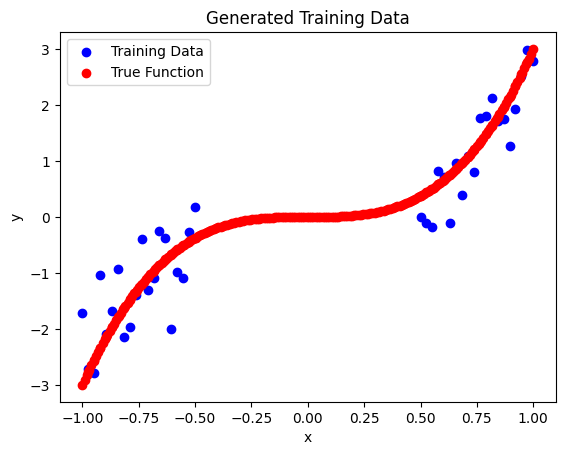

In [4]:
# data generation
x_train, y_train, x_test = generate_data(number_of_points=20, noise_variance=0.3)

# data visualization
plt.scatter(x_train, y_train, color='blue', label='Training Data')
plt.scatter(x_test, 3 * x_test**3, color='red', label='True Function')
plt.title('Generated Training Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()



### 1. Effect of Model Complexity

1. **(Effect of Model Complexity)** Generate a toy dataset with 40 observations (set the parameter `number_of_points=20` for `generate_data`, since twice the number of `number_of_points` will be generated), then  visualize the fit of MLE polynomial models, with degrees $D = [1, 3, 5, 10, 15, 20, 50, 100]$ - you should train on `x_train` and **visualize by predicting on `x_test` provided by the data generating function (`x_test` is a larger set of test points that includes `x_train`)**. You'll need to be thoughtful about your visualization so that these different models can be visually compared in a meaningful way. <br><br>
Discuss the effect of the choice of polynomial degree on the fit of the model (concretely describe why certaint choices are unideal in the context of the problem).

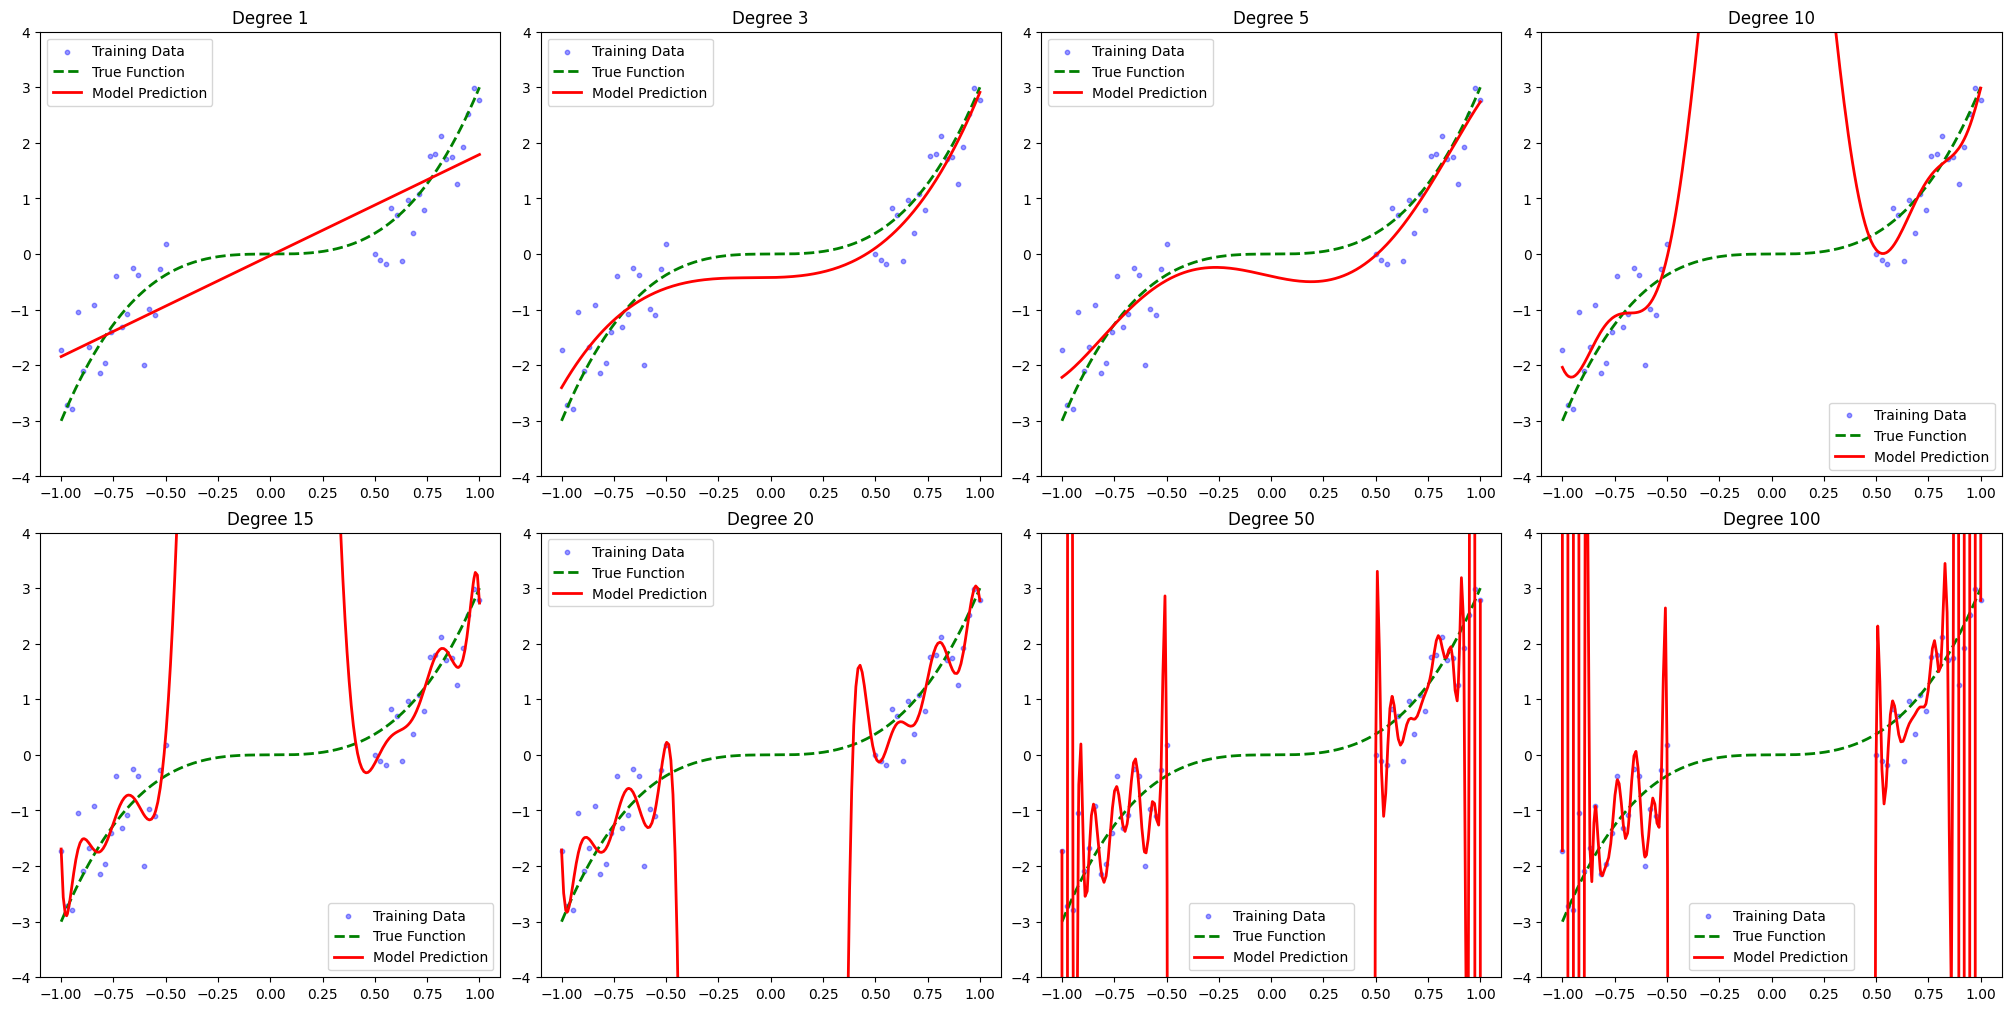

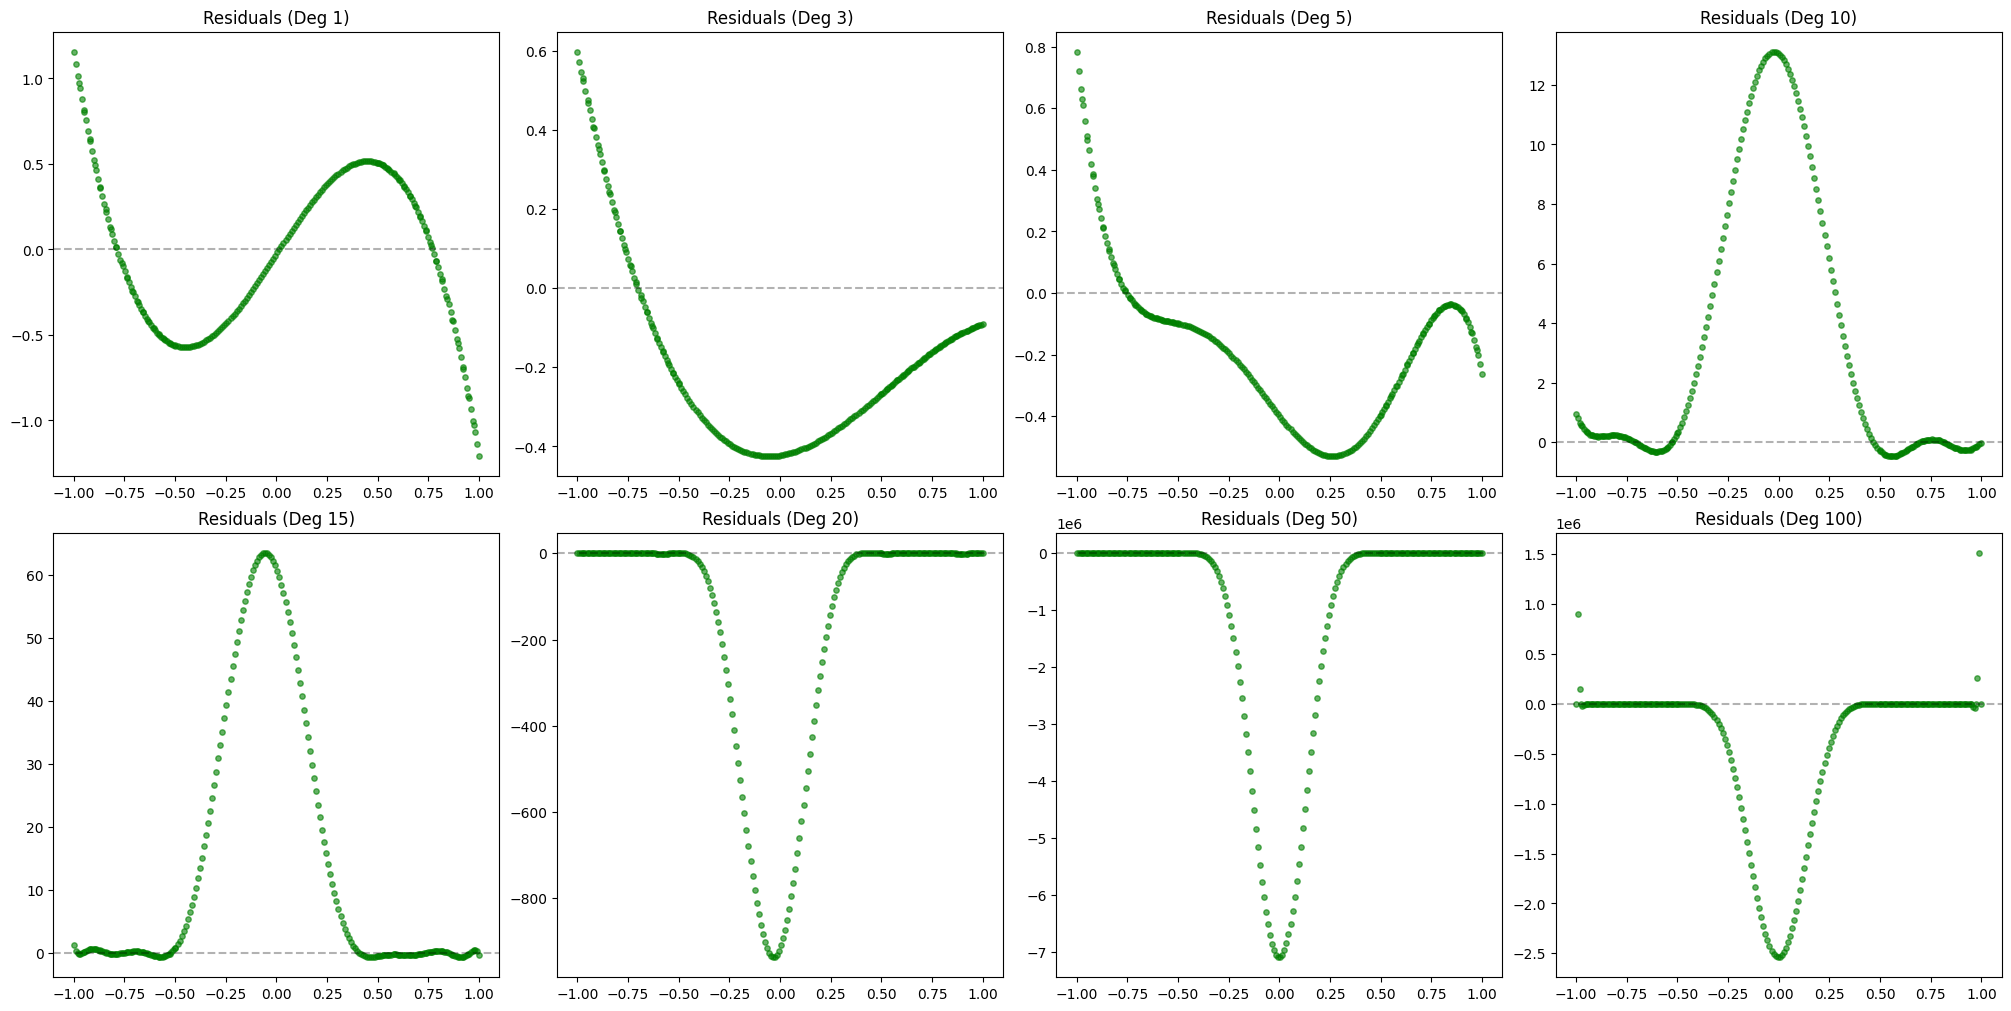

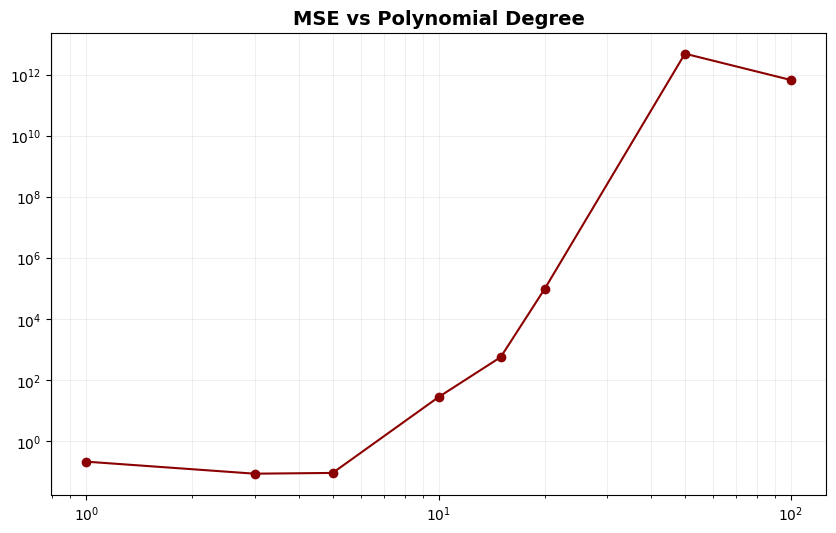

In [5]:
D = [1, 3, 5, 10, 15, 20, 50, 100]
mse_errors = []

fig1, axes1 = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes1 = axes1.flatten()
axes2 = axes2.flatten()

#function relating x and y
def ground_truth(x):
    return 3 * x**3

for i, d in enumerate(D):
    # create polynomial features
    poly = PolynomialFeatures(degree=d, include_bias=True)
    x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
    x_test_poly = poly.transform(x_test.reshape(-1, 1))

    # fit linear regression model
    model = LinearRegression(fit_intercept=False)
    model.fit(x_train_poly, y_train)
    y_test_pred = model.predict(x_test_poly)

    #residuals against noise-free ground truth
    y_true = ground_truth(x_test)
    residuals = y_test_pred - y_true
    mse_errors.append(np.mean(residuals**2))

    #biais variance trade-off
    ax1 = axes1[i]
    ax1.scatter(x_train, y_train, color='blue', s=10, alpha=0.4, label='Training Data')
    ax1.plot(x_test, ground_truth(x_test), 'g--', label='True Function', linewidth=2)
    ax1.plot(x_test, y_test_pred, color='red', lw=2, label='Model Prediction')
    ax1.set_title(f'Degree {d}')
    ax1.set_ylim(-4, 4)
    ax1.legend()
    #error pattern
    ax2 = axes2[i]
    ax2.scatter(x_test, residuals, color='green', s=15, alpha=0.6)
    ax2.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax2.set_title(f'Residuals (Deg {d})')

# error according degree
plt.figure(figsize=(10, 6))
plt.plot(D, mse_errors, marker='o', color='darkred')
plt.xscale('log')
plt.yscale('log')
plt.title('MSE vs Polynomial Degree', fontsize=14, fontweight='bold')
plt.grid(True, which="both", alpha=0.2)
plt.show()


<div style="background-color: #dde3fb; padding: 10px; border-radius: 5px; color: black;">
On the first plot, we observe that the degree 1 may seem a little bit two simple, that is to say underfitting. The models of degree 3 and 5 seems to be quite near of the data points. For the other fit, especially above degree 10, the models try too much to go throught each points what give a great example of overfitting. 

Smallest and most constant residuals seems to be the one linked to degree 3. Above degree 5, all residuals become larger and larger exponentially. 

My hypothesis is confirmed when we plot the MSE function to the polynomial degree. We can see that the error is the smallest for degree 3, and then it grows exponentially with the degree of the polynomial (log scale).
</div>

### 2. Model selection

2. **(Model Selection)** Later in the course, we will study a number of metrics commonly used for selecting between different MLE models. All of these metric essentially encode Occam's Razor: select the minimal complexity of model that satisfies some pre-determined modeling goal. <br><br>
For now, a very simple method for selecting the optimal degree is via cross-validation (by bootstrap):

  1. randomly sample two datasets, `x_train`, `x_valid`, from the data generating function: one for training and one for validation. Fit an MLE  polynomial model of degree $d$ on the training data and evaluate its performance on the validation data. Over $S$ number of such randomly sampled pairs of datasets, average the model's validation performance.
  2. plot the validation score as a function of model complexity, the polynomial degree $d$.
  3. based on the plot, select the the minimal degree that achieves a high average validation performance (i.e. look for the 'elbow' of the plot).

  Explain why performing model selection by cross-validation mitigates the risk of choosing an undesirable polynomial (identified in Problem 1)?<br><br>
  Implement model selection by cross-validation for the toy dataset generated in Problem 1 using MSE as your performance metric and select an optimal degree from $D=[1,3,5,10,15,20,50,100]$.

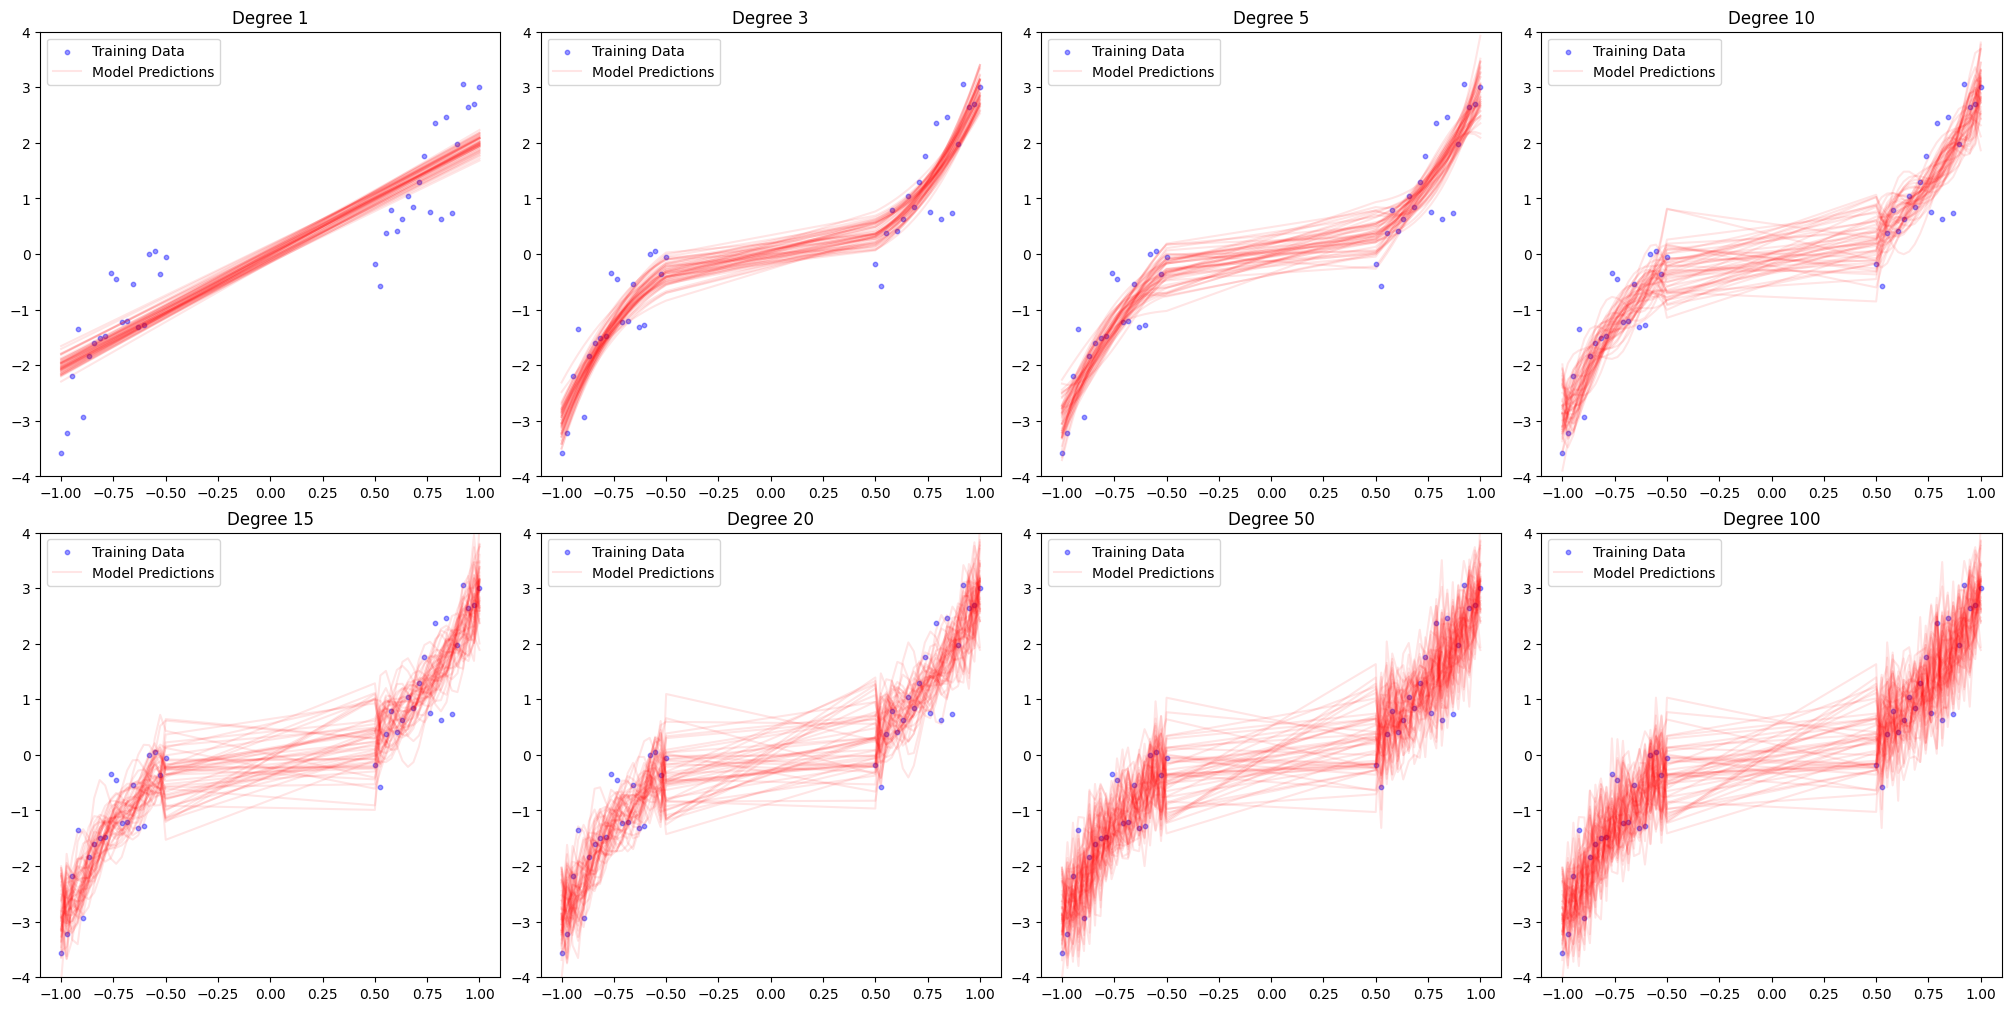

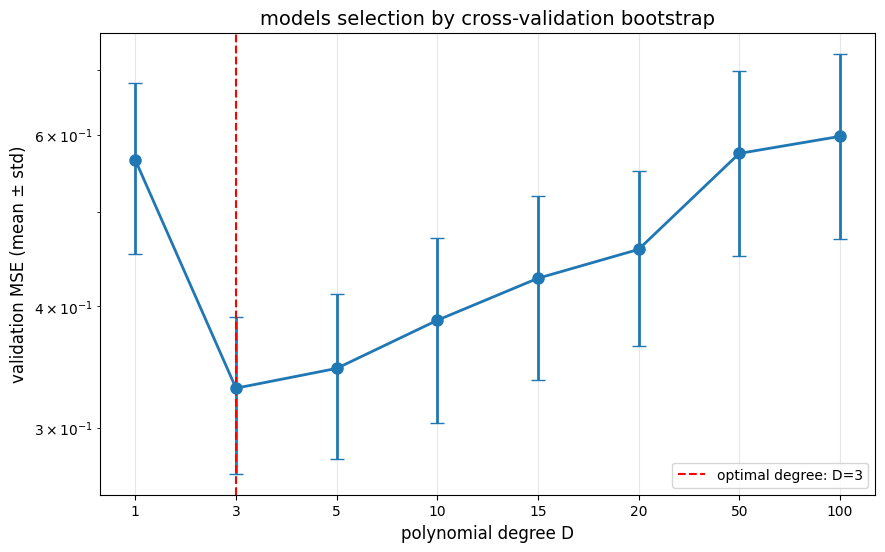

optimal degree selected: D = 3
mean MSE at optimal degree: 0.3294


In [6]:
# boostraping and cross validation method
D= [1, 3, 5, 10, 15, 20, 50, 100]
S=50
mse_errors_cv = {d: [] for d in D}
model_d = {d: [] for d in D}

for s in range(S):
    # randomly split the data into training and validation sets
    np.random.seed(s)
    x_train, y_train, _ = generate_data(number_of_points=20, noise_variance=0.3)
    
    # validation data
    np.random.seed(s + 1000)  # different seed for validation set
    x_validation, y_validation, _ = generate_data(number_of_points=20, noise_variance=0.3)
    
    for d in D:
        poly = PolynomialFeatures(degree=d, include_bias=True)
        x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
        x_validation_poly = poly.transform(x_validation.reshape(-1, 1))

        # model fitting and prediction
        model = LinearRegression(fit_intercept=False)
        model.fit(x_train_poly, y_train)
        y_validation_pred = model.predict(x_validation_poly)

        # compute validation error (MSE)
        validation_error = np.mean((y_validation_pred - y_validation) ** 2)
        mse_errors_cv[d].append(validation_error)
        model_d[d].append(y_validation_pred)

# for a given degree d, visualize the different fits obtained over the bootstrap samples
fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes = axes.flatten() 

for i, d in enumerate(D):    
    # visualisation of the different fits for each degree
    ax1 = axes[i]
    ax1.scatter(x_train, y_train, color="blue", s=10, alpha=0.4, label="Training Data")
    for sample_pred in model_d[d]:
        ax1.plot(x_validation, sample_pred, color="red", alpha=0.1, label="Model Predictions" if sample_pred is model_d[d][0] else "")
    ax1.set_title(f"Degree {d}")
    ax1.set_ylim(-4, 4)
    ax1.legend()  

mean_mse_cv = {d: np.mean(errors) for d, errors in mse_errors_cv.items()}
mean_std_cv = {d: np.std(errors) for d, errors in mse_errors_cv.items()}

# visualisation of the mean and std of the MSE for each degree
plt.figure(figsize=(10, 6))
plt.errorbar(range(len(D)), mean_mse_cv.values(), yerr=mean_std_cv.values(), marker="o", capsize=5, linewidth=2, markersize=8)
plt.xticks(range(len(D)), D)
plt.xlabel("polynomial degree D", fontsize=12)
plt.ylabel("validation MSE (mean ± std)", fontsize=12)
plt.title("models selection by cross-validation bootstrap", fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale("log")

# Identifier le degré optimal (coude)
optimal_idx = np.argmin(list(mean_mse_cv.values()))
optimal_degree = D[optimal_idx]
plt.axvline(x=optimal_idx, color="r", linestyle="--", label=f"optimal degree: D={optimal_degree}")
plt.legend()
plt.show()

print(f"optimal degree selected: D = {optimal_degree}")
print(f"mean MSE at optimal degree: {mean_mse_cv[optimal_degree]:.4f}")

#### **Explain why performing model selection by cross-validation mitigates the risk of choosing an undesirable polynomial (identified in Problem 1)?**

<div style="background-color: #dde3fb; padding: 10px; border-radius: 5px; color: black;">

Performing model selection by cross-validation helps to **mitigate the risk of choosing an undesirable polynomial** by providing a more robust estimate of the model's performance on unseen data. In Problem 1, we observed that certain polynomial degrees led to overfitting or underfitting the training data. By using cross-validation, we can evaluate **how well each polynomial degree generalizes to new data** (the validation set) rather than just fitting the training data. Moreover, cross-validation **averages the performance over multiple splits of the data**, which reduce the variance in the performance estimate and helps to identify a polynomial degree that balances bias and variance effectively. This approach allows us to **select a model that is more likely to perform well in real-world** scenarios where the data distribution may differ from the training set, thus reducing the risk of selecting a polynomial that either overfits or underfits the data.

</div>

### 3. Uncertainty estimation

3. **(Uncertainty Estimation)** We often use the bootstrap predictive uncertainty of MLE models as an indicator of our confidence in the model's output. Increasingly, in practice, decisions making are deferred to human experts when the model's predictive uncertainty is too high. <br><br>
Given your understanding of the dataset (`x_train` and `x_test`), describe what the model uncertainty ***should*** ideally look like across the input space (i.e. if you plotted the model uncertainty as a function of $x$, what would it look like)? Justify your answer: consider the context of the problem - the test input has undergone covariate shift and is dissmilar to the training input, what kind of uncertainty would help you mitigate risk under this condition?<br><br>
A common practice for estimating predictive uncertainty is to fit a large number of (bootstrap) models on the training data (this collection of models is called an **ensemble**), then, at an input $x$, use the variance of the ensemble predictions to estimate the uncertainty at $x$. Plot the 95% predictive interval of 200 bootstrap MLE polynomial models for each degree $D=[1,3,5,10,15,20,50,100]$, arrange your plots as  subplots in a single figure. For which polynomial degree do you obtain the predictive uncertainty that is most ideal (according to your description above)? Is this the degree you selected in Problem 2? Explain why you would or would not expect the optimal degree in Problem 2 to yield the most ideal uncertainty estimate.<br><br>
Make the same plots the 95% predictive intervals for degrees $D=[1,3,5,10,15,20,50,100]$, with models fitted on larger training datasets - set `number_of_points` to 50, 100, 500, 1000 (arrange all these plots in a single figure). What is happening to the predictions of the ensemble in the training data rich region? What is happening to the predictions of the ensemble in the training data poor region? Are these expected behaviours (relate what you see in both cases to the asymptotic properties of MLE)?
<br><br>
When the training data is abundant (`number_of_points=1000`), are any of the 95% predictive intervals ideal (according to your description above)? What does this imply about the feasibility of using the variance of the ensemble predictions to estimate predictive uncertainty at an input $x$?

#### **Given your understanding of the dataset (`x_train` and `x_test`), describe what the model uncertainty ***should*** ideally look like across the input space (i.e. if you plotted the model uncertainty as a function of $x$, what would it look like)? Justify your answer: consider the context of the problem - the test input has undergone covariate shift and is dissmilar to the training input, what kind of uncertainty would help you mitigate risk under this condition?**

<div style="background-color: #dde3fb; padding: 10px; border-radius: 5px; color: black;">

The model uncertainty should ideally be low in the regions of the input space where we have training data ([-1, -0.5] and [0.5, 1]) and high in the regions where we have no training data (i.e., within the gap of [-0.5, 0.5]). This is because the model has seen data in the regions outside the gap and can make more confident predictions there, while it has not seen any data in the gap and thus should be less confident in its predictions there. This kind of uncertainty would help mitigate risk under covariate shift by flagging unreliable predictions in the gap region, allowing for human intervention or deferring decisions to experts when the model is uncertain.

As we can observe in the plots above, uncertainty is low in the [-0.5, 0.5] gap for the lower degree polynomials (1, 3, 5), which appears ideal at first glance but is fundamentally problematic: the model is overconfident in a region where it has no training data. The bootstrap variance fails to capture the epistemic uncertainty (lack of knowledge) that should exist in the gap.
For higher degree polynomials (10, 15, 20, 50, 100), the uncertainty is high in the gap, which correctly reflects the model's lack of knowledge in that region. However, for very high degrees (50, 100), the uncertainty becomes excessively high even in the regions with abundant training data, which is also problematic. This excessive uncertainty stems from model instability (overfitting): the high flexibility allows each bootstrap sample to fit wildly different functions, creating variance everywhere, not just where we lack data.

Thus, we face a fundamental trade-off: low-degree polynomials provide good predictive performance but underestimate uncertainty under covariate shift, while high-degree polynomials exhibit high uncertainty in the gap but suffer from poor predictions due to overfitting. No single polynomial degree yields both accurate predictions and ideal uncertainty estimates.

</div>

#### **A common practice for estimating predictive uncertainty is to fit a large number of (bootstrap) models on the training data (this collection of models is called an **ensemble**), then, at an input $x$, use the variance of the ensemble predictions to estimate the uncertainty at $x$. Plot the 95% predictive interval of 200 bootstrap MLE polynomial models for each degree $D=[1,3,5,10,15,20,50,100]$, arrange your plots as  subplots in a single figure**

To better understand, let's plot the 95% predictive intervals for degrees D=[1,3,5,10,15,20,50,100] with models fitted on larger training datasets (number_of_points=50, 100, 500, 1000).

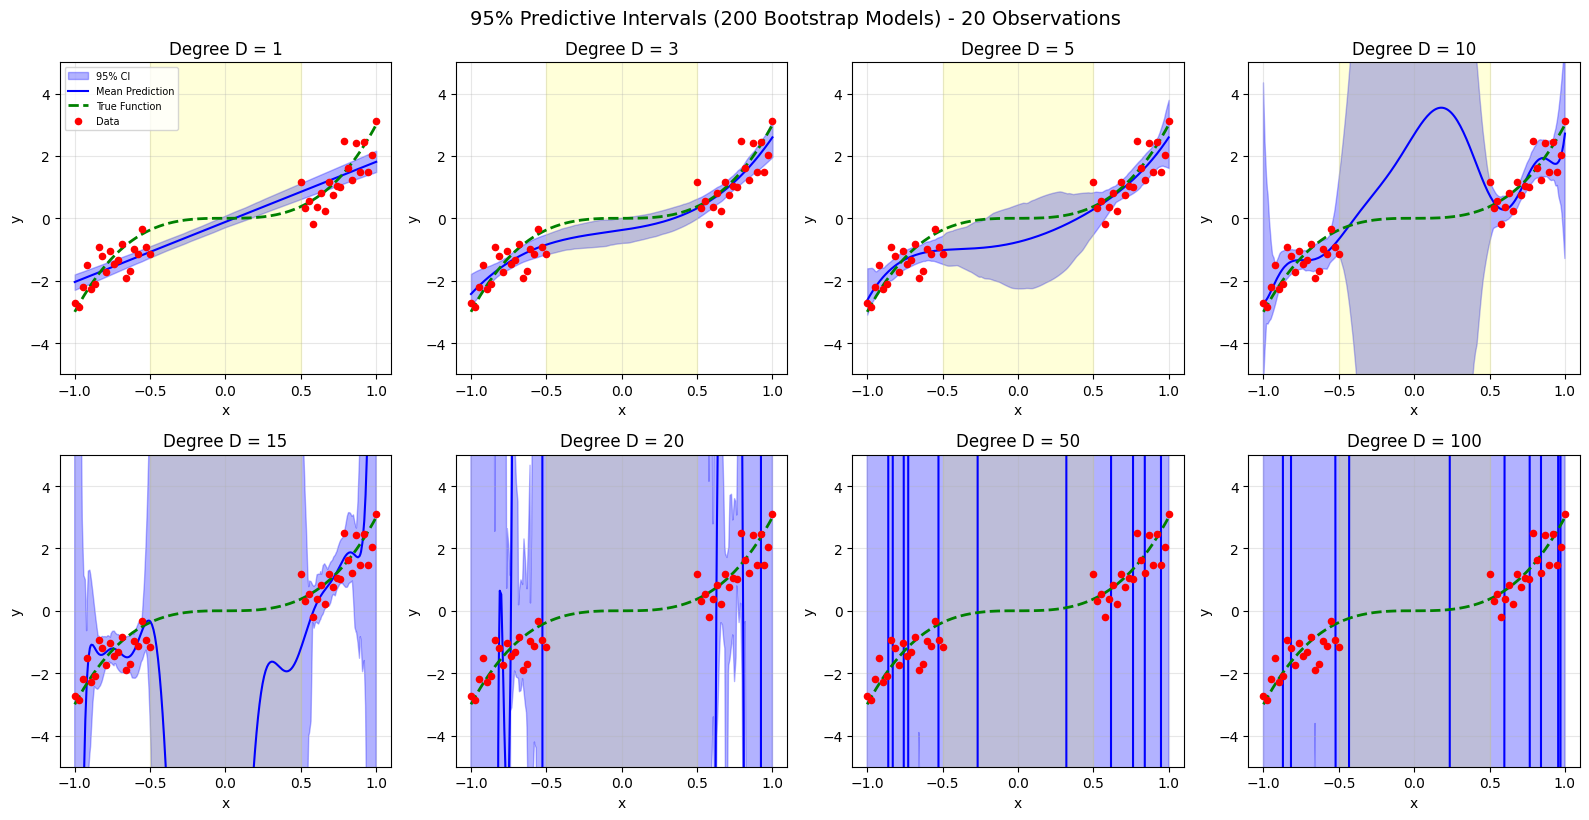

In [15]:
# boostraping and uncertainty estimation for model selection
D= [1, 3, 5, 10, 15, 20, 50, 100]

def bootstrap_model_selection(x_train, y_train, x_test, d, S):
    predictions = {d: [] for d in D}

    n_samples = len(x_train)

    for s in range(S):
        # create a bootstrap sample
        np.random.seed(s)
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        x_train_bootstrap = x_train[indices]
        y_train_bootstrap = y_train[indices]

        # create polynomial features
        poly = PolynomialFeatures(degree=d, include_bias=True)
        x_train_poly = poly.fit_transform(x_train_bootstrap.reshape(-1, 1))
        x_test_poly = poly.transform(x_test.reshape(-1, 1))

        #model fitting and prediction
        model = LinearRegression(fit_intercept=False,  n_jobs=-1)
        model.fit(x_train_poly, y_train_bootstrap)
        y_test_pred = model.predict(x_test_poly)

        #save predictions for each degree
        predictions[d].append(y_test_pred)
    return predictions

np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=20, noise_variance=0.3)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, d in enumerate(D):
    predictions = bootstrap_model_selection(x_train, y_train, x_test, d, S=200)
    
    # compute mean and 95% predictive interval
    mean_pred = np.mean(predictions[d], axis=0)
    lower = np.percentile(predictions[d], 2.5, axis=0)
    upper = np.percentile(predictions[d], 97.5, axis=0)
    
    ax = axes[i]
    ax.fill_between(x_test, lower, upper, alpha=0.3, color="blue", label="95% CI")
    ax.plot(x_test, mean_pred, "b-", linewidth=1.5, label="Mean Prediction")
    ax.plot(x_test, 3*x_test**3, "g--", linewidth=2, label="True Function")
    ax.scatter(x_train, y_train, c="red", s=20, zorder=5, label="Data")
    ax.axvspan(-0.5, 0.5, alpha=0.15, color="yellow")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-5, 5)
    ax.set_title(f"Degree D = {d}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.suptitle("95% Predictive Intervals (200 Bootstrap Models) - 20 Observations", y=1.02, fontsize=14)
plt.show()

#### **For which polynomial degree do you obtain the predictive uncertainty that is most ideal (according to your description above)? Is this the degree you selected in Problem 2? Explain why you would or would not expect the optimal degree in Problem 2 to yield the most ideal uncertainty estimate.**

<div style="background-color: #dde3fb; padding: 10px; border-radius: 5px; color: black;">

The 10 degree polynomial seems to provide the most ideal predictive uncertainty. It captures the low uncertainty in the regions with training data and high uncertainty in the gap, which aligns with our expectations under covariate shift. In problem 2, we identified degree 3 as the optimal degree based on validation performance. However, degree 3 underestimates uncertainty in the gap region, which is a critical issue under covariate shift. This discrepancy arises because model selection based on validation performance focuses on predictive accuracy rather than uncertainty estimation. The optimal degree for prediction may not be the optimal degree for uncertainty estimation, especially in scenarios with covariate shift where capturing epistemic uncertainty is crucial for risk mitigation.

</div>

#### **Make the same plots the 95% predictive intervals for degrees $D=[1,3,5,10,15,20,50,100]$, with models fitted on larger training datasets - set `number_of_points` to 50, 100, 500, 1000 (arrange all these plots in a single figure).**

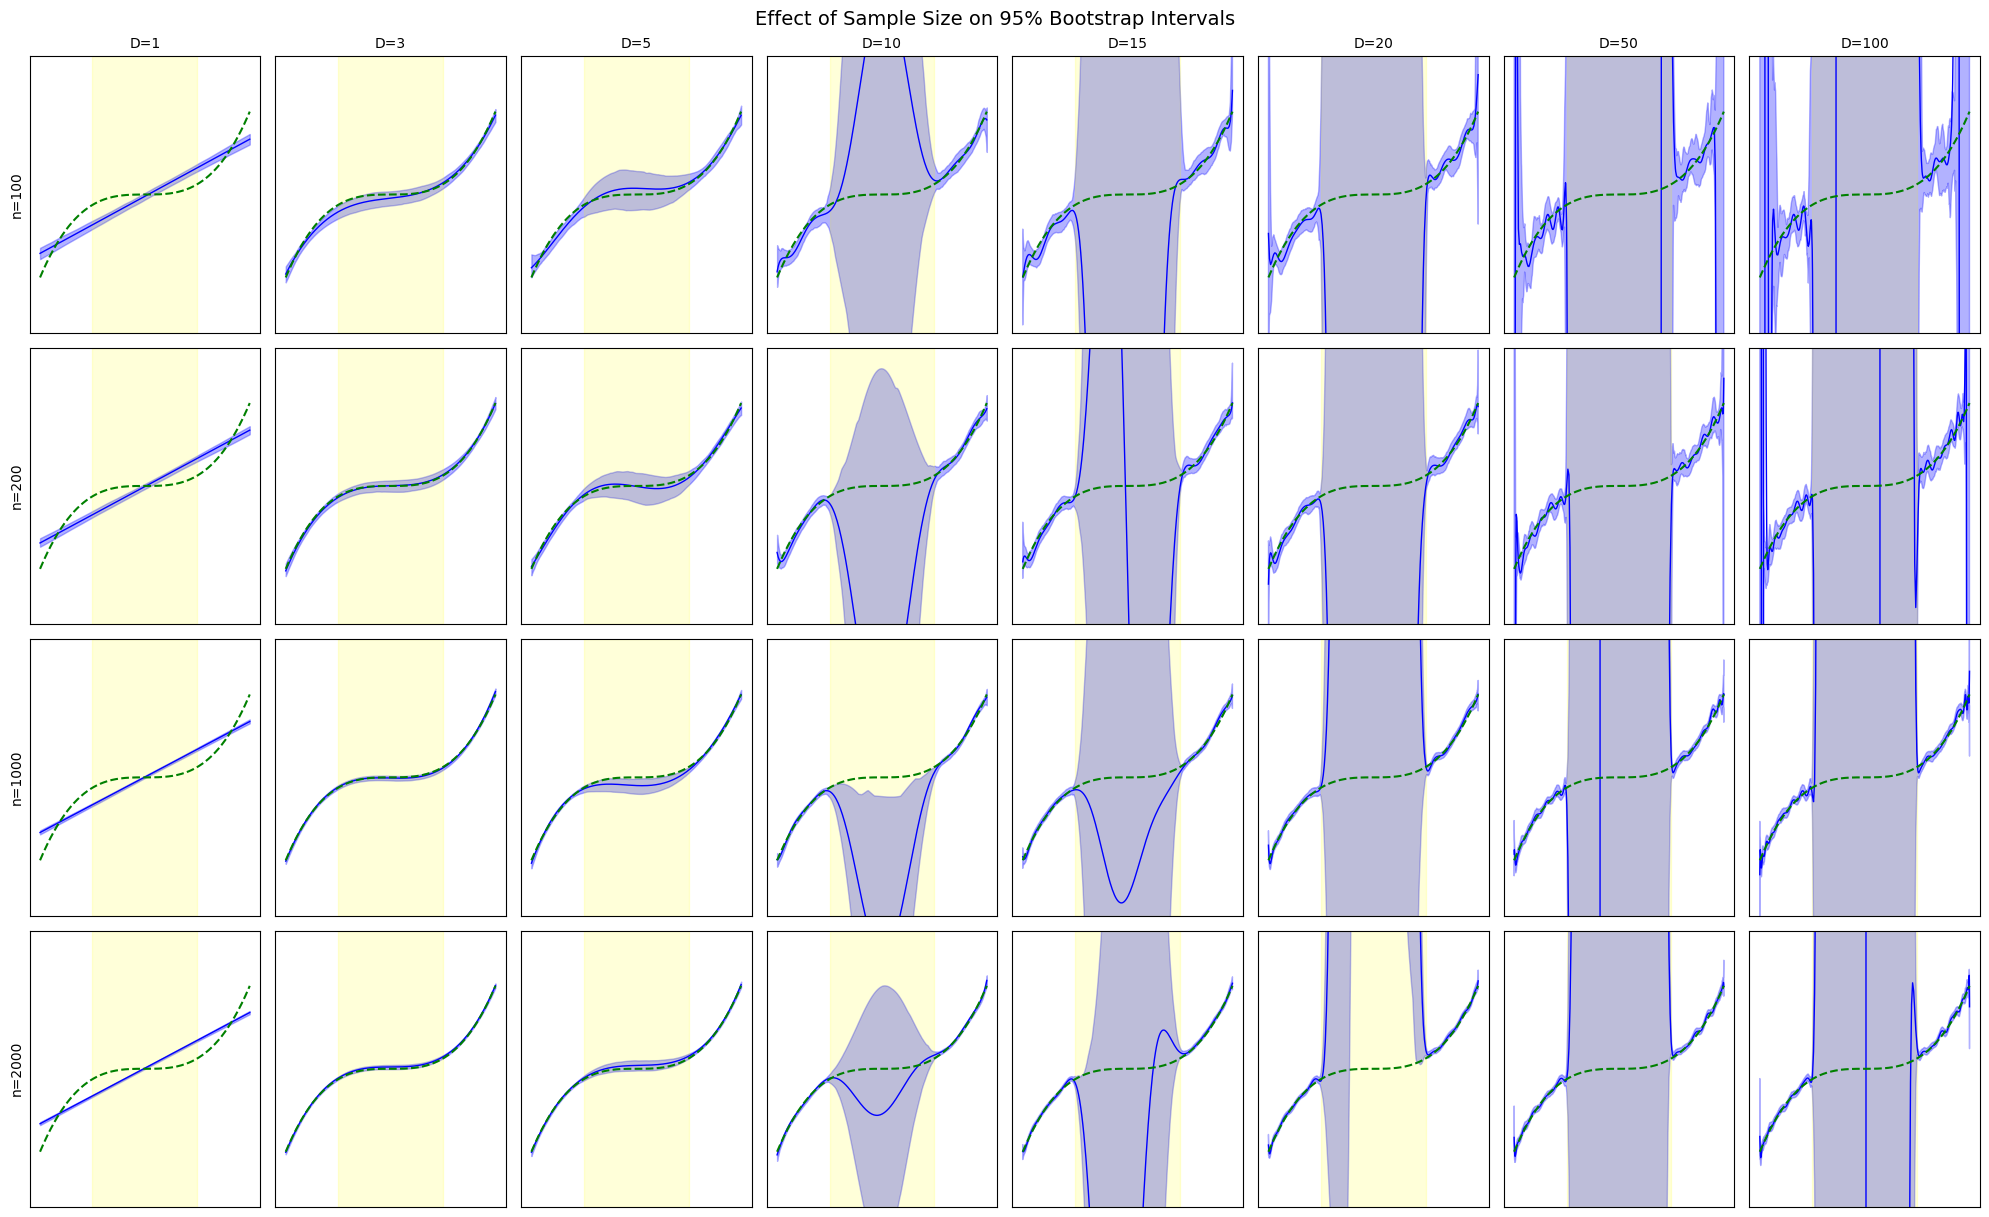

In [14]:
np.random.seed(42)
number_of_points = [50, 100, 500, 1000]

fig, axes = plt.subplots(len(number_of_points), len(D), figsize=(20, 12))

for row, n_points in enumerate(number_of_points):
    np.random.seed(42)
    x_train, y_train, x_test = generate_data(number_of_points=n_points)
    
    for col, d in enumerate(D):
        predictions = bootstrap_model_selection(x_train, y_train, x_test, d, S=200)
        
        mean_pred = np.mean(predictions[d], axis=0)
        lower = np.percentile(predictions[d], 2.5, axis=0)
        upper = np.percentile(predictions[d], 97.5, axis=0)
        
        ax = axes[row, col]
        ax.fill_between(x_test, lower, upper, alpha=0.3, color="blue")
        ax.plot(x_test, mean_pred, "b-", linewidth=1)
        ax.plot(x_test, 3*x_test**3, "g--", linewidth=1.5)
        ax.axvspan(-0.5, 0.5, alpha=0.15, color="yellow")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        if row == 0:
            ax.set_title(f"D={d}", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"n={2*n_points}", fontsize=10)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.suptitle("Effect of Sample Size on 95% Bootstrap Intervals", y=1.01, fontsize=14)
plt.show()

#### **What is happening to the predictions of the ensemble in the training data rich region? What is happening to the predictions of the ensemble in the training data poor region? Are these expected behaviours (relate what you see in both cases to the asymptotic properties of MLE)?**

<div style="background-color: #dde3fb; padding: 10px; border-radius: 5px; color: black;">

In the training data rich regions ([-1, -0.5] and [0.5, 1]), as the number of training points increases (50 to 1000), the predictions of the ensemble become more stable and converge towards the true underlying function. This is expected due to the asymptotic properties of MLE: as the sample size increases, the MLE estimates converge to the true parameter values, leading to more accurate predictions and reduced variance in those predictions.

In the training data poor region (the gap of [-0.5, 0.5]), the predictions of the ensemble become also more stable as we can see on the 10 degree polynomial plot. However, this behavior is problematic: the model is becoming more confident in a region where it has no training data. The models become more and more confidant even using extrapolated data. This is a consequence of the fact that MLE does not capture epistemic uncertainty (lack of knowledge) in regions without data, and as we increase the number of training points, the model becomes more certain about its predictions even in the gap, which is a critical issue under covariate shift.

</div>

#### **When the training data is abundant (`number_of_points=1000`), are any of the 95% predictive intervals ideal (according to your description above)? What does this imply about the feasibility of using the variance of the ensemble predictions to estimate predictive uncertainty at an input $x$?**

<div style="background-color: #dde3fb; padding: 10px; border-radius: 5px; color: black;">

No, even when the number of points is abundant, none of the 95% predictive intervals are ideal. The low-degree polynomials (1, 3, 5) still underestimate uncertainty in the gap region, while the high-degree polynomials (50, 100) exhibit either very high uncertainty in the gap, either uncertainty doesn't even contain the true function in the training data poor region (D=10, s=1000). This implies that using the variance of the ensemble predictions to estimate predictive uncertainty at an input $x$ is not always feasible, especially under covariate shift. The bootstrap variance fails to capture epistemic uncertainty in regions without data, and can also be inflated due to model instability in high-degree polynomials, leading to unreliable uncertainty estimates.

</div>

### Effect of regularization

4. **(Effect of Regularization)** In practice, MLE models are nearly always trained with regularization (since they tend to overfit to the training data). Here, we will explore the effect of adding $\ell_2$ regularization to our MLE polynomial models (that is, use the `Ridge` regression model from `sklearn` after augmenting your input with polynomial features). <br><br>
For a toy dataset with 40 observations (`number_of_points=20`), plot the 95% predictive intervals for degrees $D = [1,3,5,10,15,20,50,100]$ and regularization strengths `alpha = [5e-3, 1e-2, 1e-1, 1e0, 1e1]` (you should organize these plots in a grid).<br><br>
Describe the effect of regularization on the bootstrap uncertainties. Looking at these results, are the goals of $\ell_2$ regularization and obtaining useful predictive uncertatinty estimation neccessarily well-aligned?


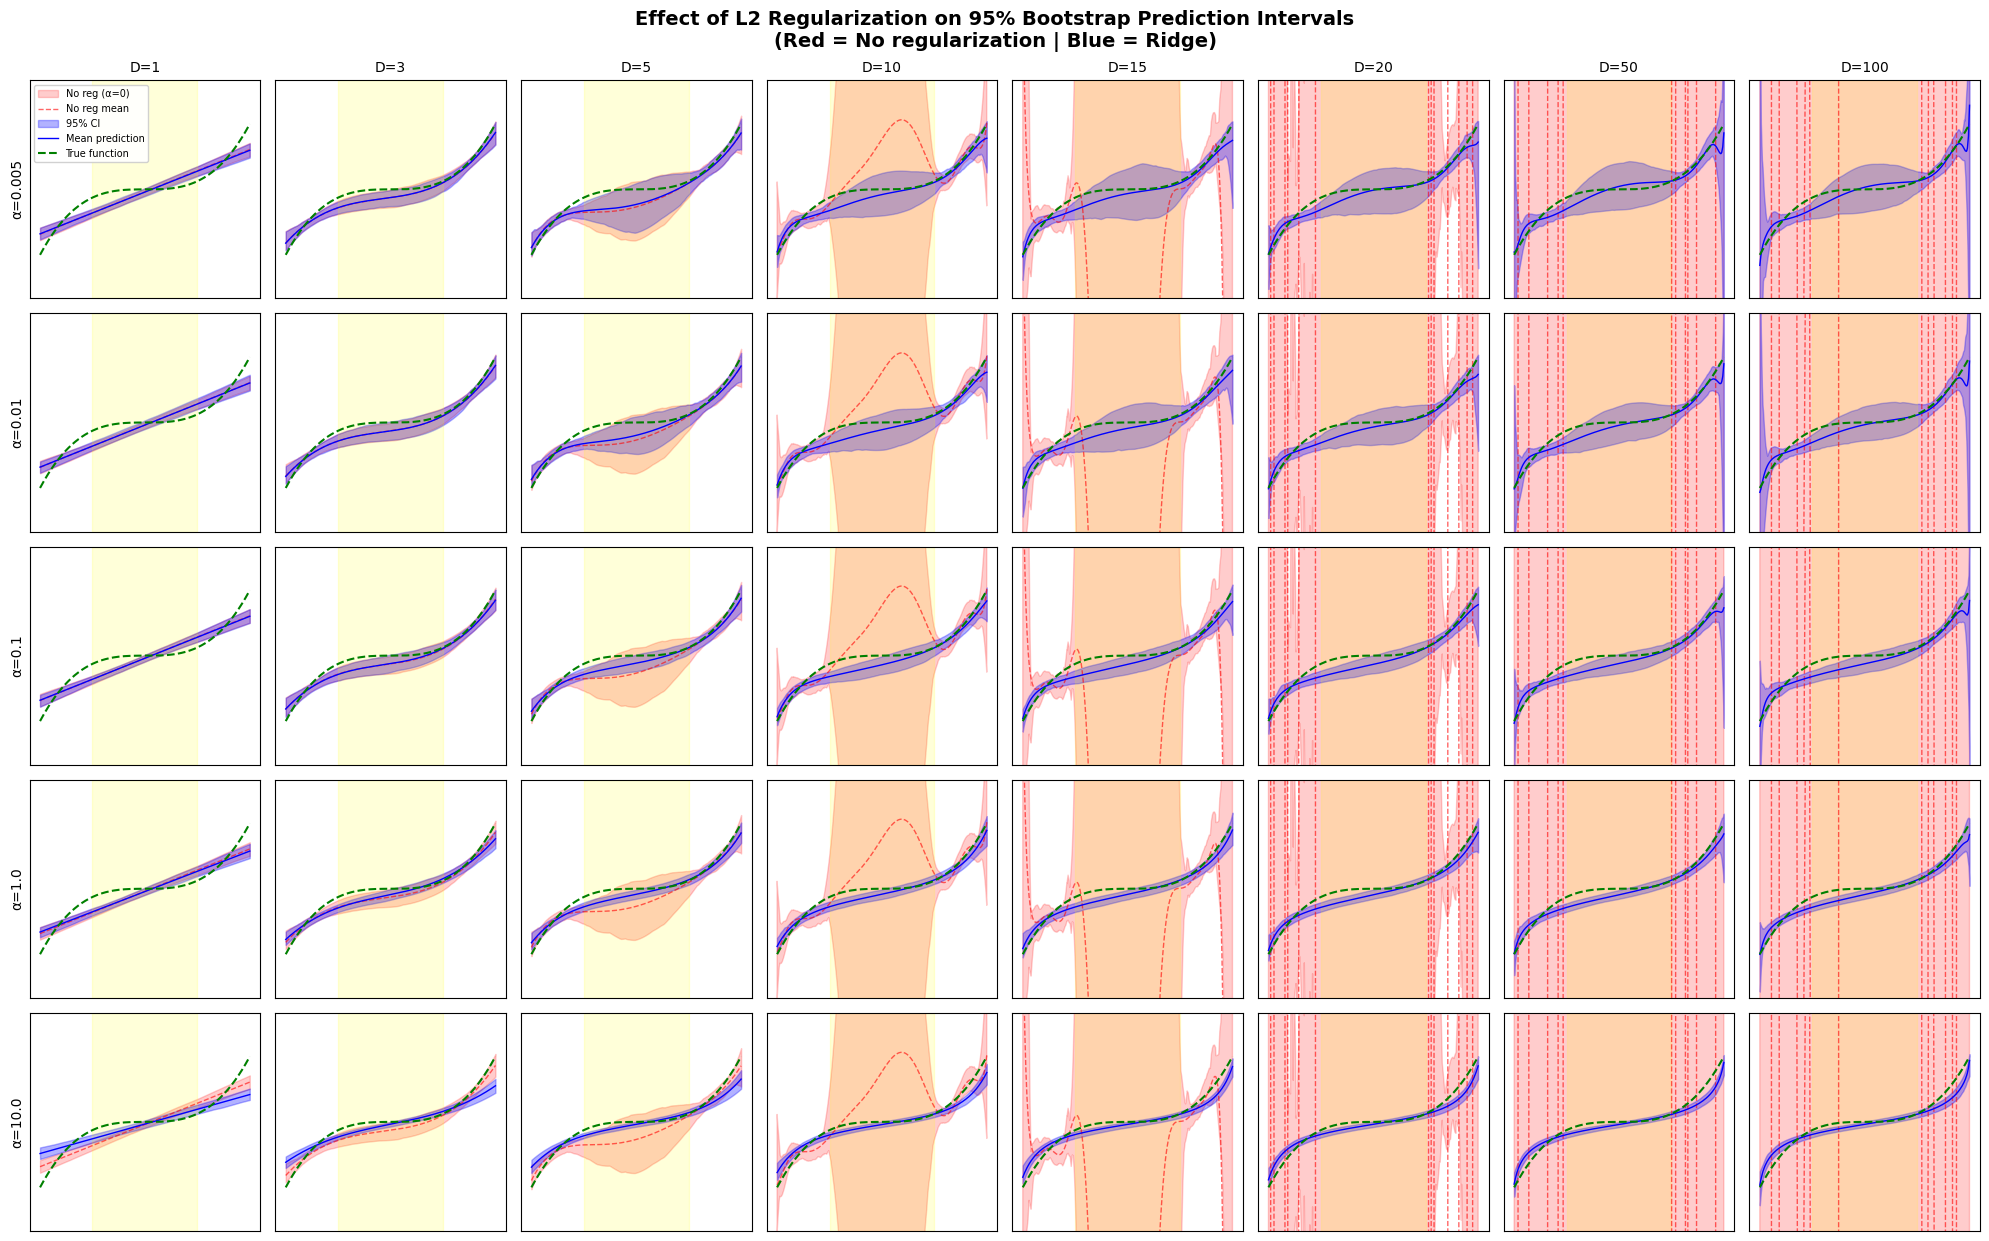

In [25]:
# generate single dataset for all experiments
np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=20, noise_variance=0.3)

# regularization strengths and polynomial degrees
alphas = [5e-3, 1e-2, 1e-1, 1e0, 1e1]
D = [1, 3, 5, 10, 15, 20, 50, 100]

def bootstrap_ensemble_model_ridge_regularized(x_train, y_train, x_test, degree, alpha=None, n_bootstrap=200):
    n = len(x_train)
    predictions = np.zeros((n_bootstrap, len(x_test)))
    
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    if alpha is None:
        model = LinearRegression(fit_intercept=False)
    else:
        model = Ridge(alpha=alpha, fit_intercept=False)
    
    for b in range(n_bootstrap):
        #bootstrap sample (with replacement)
        idx = np.random.choice(n, size=n, replace=True)
        x_b = x_train[idx]
        y_b = y_train[idx]
        
        #transform and fit
        X_b_poly = poly.fit_transform(x_b.reshape(-1, 1))
        X_test_poly = poly.transform(x_test.reshape(-1, 1))
        
        model.fit(X_b_poly, y_b)
        predictions[b] = model.predict(X_test_poly)
    
    return predictions

#compute reference intervals without regularization
reference_intervals = {}
for degree in D:
    predictions_no_reg = bootstrap_ensemble_model_ridge_regularized(x_train, y_train, x_test, degree, alpha=None, n_bootstrap=200)
    reference_intervals[degree] = {
        'lower': np.percentile(predictions_no_reg, 2.5, axis=0),
        'upper': np.percentile(predictions_no_reg, 97.5, axis=0),
        'mean': np.mean(predictions_no_reg, axis=0)
    }

# visualization grid
fig, axes = plt.subplots(len(alphas), len(D), figsize=(20, 12))

for row, alpha_val in enumerate(alphas):
    for col, degree in enumerate(D):
        #get bootstrap predictions
        predictions = bootstrap_ensemble_model_ridge_regularized(x_train, y_train, x_test, degree, alpha_val, n_bootstrap=200)
        
        #compute mean and 95% CI
        mean_pred = np.mean(predictions, axis=0)
        lower = np.percentile(predictions, 2.5, axis=0)
        upper = np.percentile(predictions, 97.5, axis=0)
        
        ax = axes[row, col]
        ax.fill_between(x_test, 
                        reference_intervals[degree]['lower'], 
                        reference_intervals[degree]['upper'], 
                        alpha=0.2, color='red', label='No reg (α=0)')
        ax.plot(x_test, reference_intervals[degree]['mean'], 'r--', linewidth=1, alpha=0.6, label='No reg mean')
        ax.fill_between(x_test, lower, upper, alpha=0.3, color='blue', label='95% CI')
        ax.plot(x_test, mean_pred, 'b-', linewidth=1, label='Mean prediction')
        ax.plot(x_test, 3*x_test**3, 'g--', linewidth=1.5, label='True function')
        ax.axvspan(-0.5, 0.5, alpha=0.15, color='yellow')  # Training region
        
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        if row == 0:
            ax.set_title(f'D={degree}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'α={alpha_val}', fontsize=10)
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        if row == 0 and col == 0:
            ax.legend(loc='upper left', fontsize=7, framealpha=0.9)

plt.tight_layout()
plt.suptitle('Effect of L2 Regularization on 95% Bootstrap Prediction Intervals\n(Red = No regularization | Blue = Ridge)', y=1.03, fontsize=14, fontweight='bold')
plt.show()

#### **Describe the effect of regularization on the bootstrap uncertainties.**

<div style="background-color: #dde3fb; padding: 10px; border-radius: 5px; color: black;">  

**For low polynomial degrees (D=1, 3, 5):**
For low regularization strengths (α = 5e-3, 1e-2), the predictive intervals are quite similar to those without regularization. We observe prediction zones where the interval width increases with degree and decreases as alpha increases.
When alpha increases, the mean predictions become smoother, the confidence intervals become narrower and no longer contain the true function.

**For high polynomial degrees (D=20, 50, 100):**
For low regularization strengths, the predictive intervals are much narrower than without regularization, which is a good thing. However, for higher regularization strengths, the predictive intervals become excessively narrow and overconfident, even in the extrapolation region (outside the yellow training zone), which is problematic. This excessive confidence stems from the fact that L2 regularization penalizes large coefficients, which can lead to underfitting and a failure to capture the true underlying function, especially in regions where the model extrapolates beyond its training data.


In general, regularization reduces the variance of the model predictions, which leads to narrower predictive intervals.

</div>

#### **Looking at these results, are the goals of $\ell_2$ regularization and obtaining useful predictive uncertatinty estimation neccessarily well-aligned?**

<div style="background-color: #dde3fb; padding: 10px; border-radius: 5px; color: black;">

**No, the goals are not necessarily well-aligned.**

The primary goal of L2 regularization is to reduce overfitting by penalizing large coefficients, thereby decreasing model variance at the cost of slightly increased bias.
In contrast, useful uncertainty estimation aims to provide high uncertainty in regions where the model has limited or no data—specifically outside the training domain (the yellow region)—to honestly reflect the model's lack of confidence when extrapolating.

Since regularization reduces variance uniformly across all regions, it fails to distinguish between interpolation zones (where uncertainty should be low) and extrapolation zones (where uncertainty should be high). This is particularly problematic when α is large: the model becomes artificially overconfident everywhere, producing narrow intervals even in regions where predictions are unreliable.

For high degrees with strong regularization (bottom-right corner), the blue intervals are deceptively narrow, suggesting high confidence, yet the mean prediction (blue line) systematically deviates from the true function (green dashed line), especially in extrapolation. This narrow interval reflects only the reduced variance but completely misses the systematic bias introduced by over-regularization.

L2 regularization achieves its variance-reduction goal but at the expense of producing misleading uncertainty estimates. Bootstrap intervals after regularization capture sampling variability but fail to account for model misspecification bias, making them unreliable indicators of true predictive uncertainty.

</div>

## Part II: Bayesian Polynomial Regression
In this problem, your task is to perform Bayesian polynomial regression on the toy datasets in Part I. That is, assume that the outcome $y$ can be modeled by the following process:

\begin{align}
y &= f(x) + \epsilon = w_0 + w_1x + w_2x^2 + \ldots + w_Dx^D + \epsilon, \quad \epsilon \sim N(0, 0.3)\\
w_d &\sim N(0, \alpha)
\end{align}

where $\alpha$ is a hyperparameter and must be fixed before modeling and inference begins.

### 1. Bayesian Kernel Regression

1. **(Bayesian Kernel Regression)** Just as we can treat a polynomial regression model like a multi-linear regression model after ***transforming*** the input data by adding polynomial features. We can treat Bayesian polynomial regression like Bayesian linear regression on top of the transformed inputs. Formally, the map that takes an input $\mathbf{x}_n \in \mathbb{R}^{D'}$ and transforms it into a new input $\phi(\mathbf{x}_n) \in \mathbb{R}^{D}$ is called a **feature map**, $\phi: \mathbb{R}^{D'} \to \mathbb{R}^{D}$, for 1-dimensional input $x \in \mathbb{R}$, the polynomial feature map of degree $D$ is defined by
\begin{align}
\\\phi: \mathbb{R} &\to \mathbb{R}^D\\
x &\mapsto [1, x, x^2, \ldots, x^D]\\
\end{align}
<br> Thus, we can write rewrite Bayesian polynomial regression as
\begin{align}
\\y &= \mathbf{w}^\top \mathbf{x} + \epsilon, \quad \epsilon \sim {N}(0, 0.3)\\
\mathbf{w} &\sim {N}(0, \alpha I_{D\times D})\\
\end{align}
<br>Denote the $N\times D$ matrix of transformed inputs by $\Phi$, where the $n$-th row of the matrix is the $n$-th input $\mathbf{x}_n$ transformed by the feature map, $\phi(\mathbf{x}_n)$. 

#### **Using this notation, write out the closed form for the posterior for Bayesian polynomial regression in terms of $\Phi$.**

<div style="background-color: #dde3fb; padding: 10px; border-radius: 5px; color: black">

We have the following model:
$$y = \Phi \mathbf{w} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma^2 = 0.3$$

Prior:
$$\mathbf{w} \sim \mathcal{N}(0, \alpha I_{D\times D})$$

Likelihood:
$$\mathbf{y}|\Phi, \mathbf{w} \sim \mathcal{N}(\Phi \mathbf{w}, \sigma^2 I_{N\times N})$$

Posterior:
\begin{align}
p(\mathbf{w}|\mathbf{y}, \Phi) &\propto p(\mathbf{y}|\Phi, \mathbf{w}) p(\mathbf{w})\\
&= \mathcal{N}(\mathbf{y}|\Phi \mathbf{w}, \sigma^2 I_{N\times N}) \mathcal{N}(\mathbf{w}|0, \alpha I_{D\times D})\\
&= \mathcal{N}(\mathbf{w}|\boldsymbol{\mu}, \boldsymbol{\Sigma})
\end{align}
$$\boxed{p(\mathbf{w} | \mathbf{y}, \Phi) = \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}$$

where
$$\boxed{\boldsymbol{\Sigma} = \left(\frac{1}{\sigma^2} \Phi^\top \Phi + \frac{1}{\alpha} I_{D\times D}\right)^{-1}}$$
$$\boxed{\boldsymbol{\mu} = \boldsymbol{\Sigma} \left(\frac{1}{\sigma^2} \Phi^\top \mathbf{y}\right)}$$

</div>

### 2. Effect of Model Complexity

2. **(Effect of Model Complexity)** For Bayesian kernel regression, you need to pre-determine the number of features (i.e. $D$) and the hyperparameter $\alpha$ in the prior. For a toy dataset with 40 observations (set number_of_points=20), visualize the 95% posterior predictive interval for $D = [1,3,5,10,15,20,50,100]$ and $\alpha = [0.1, 1, 5, 10, 100]$ (arrange these visualizations in a grid), using Bayesian polynomial regression.

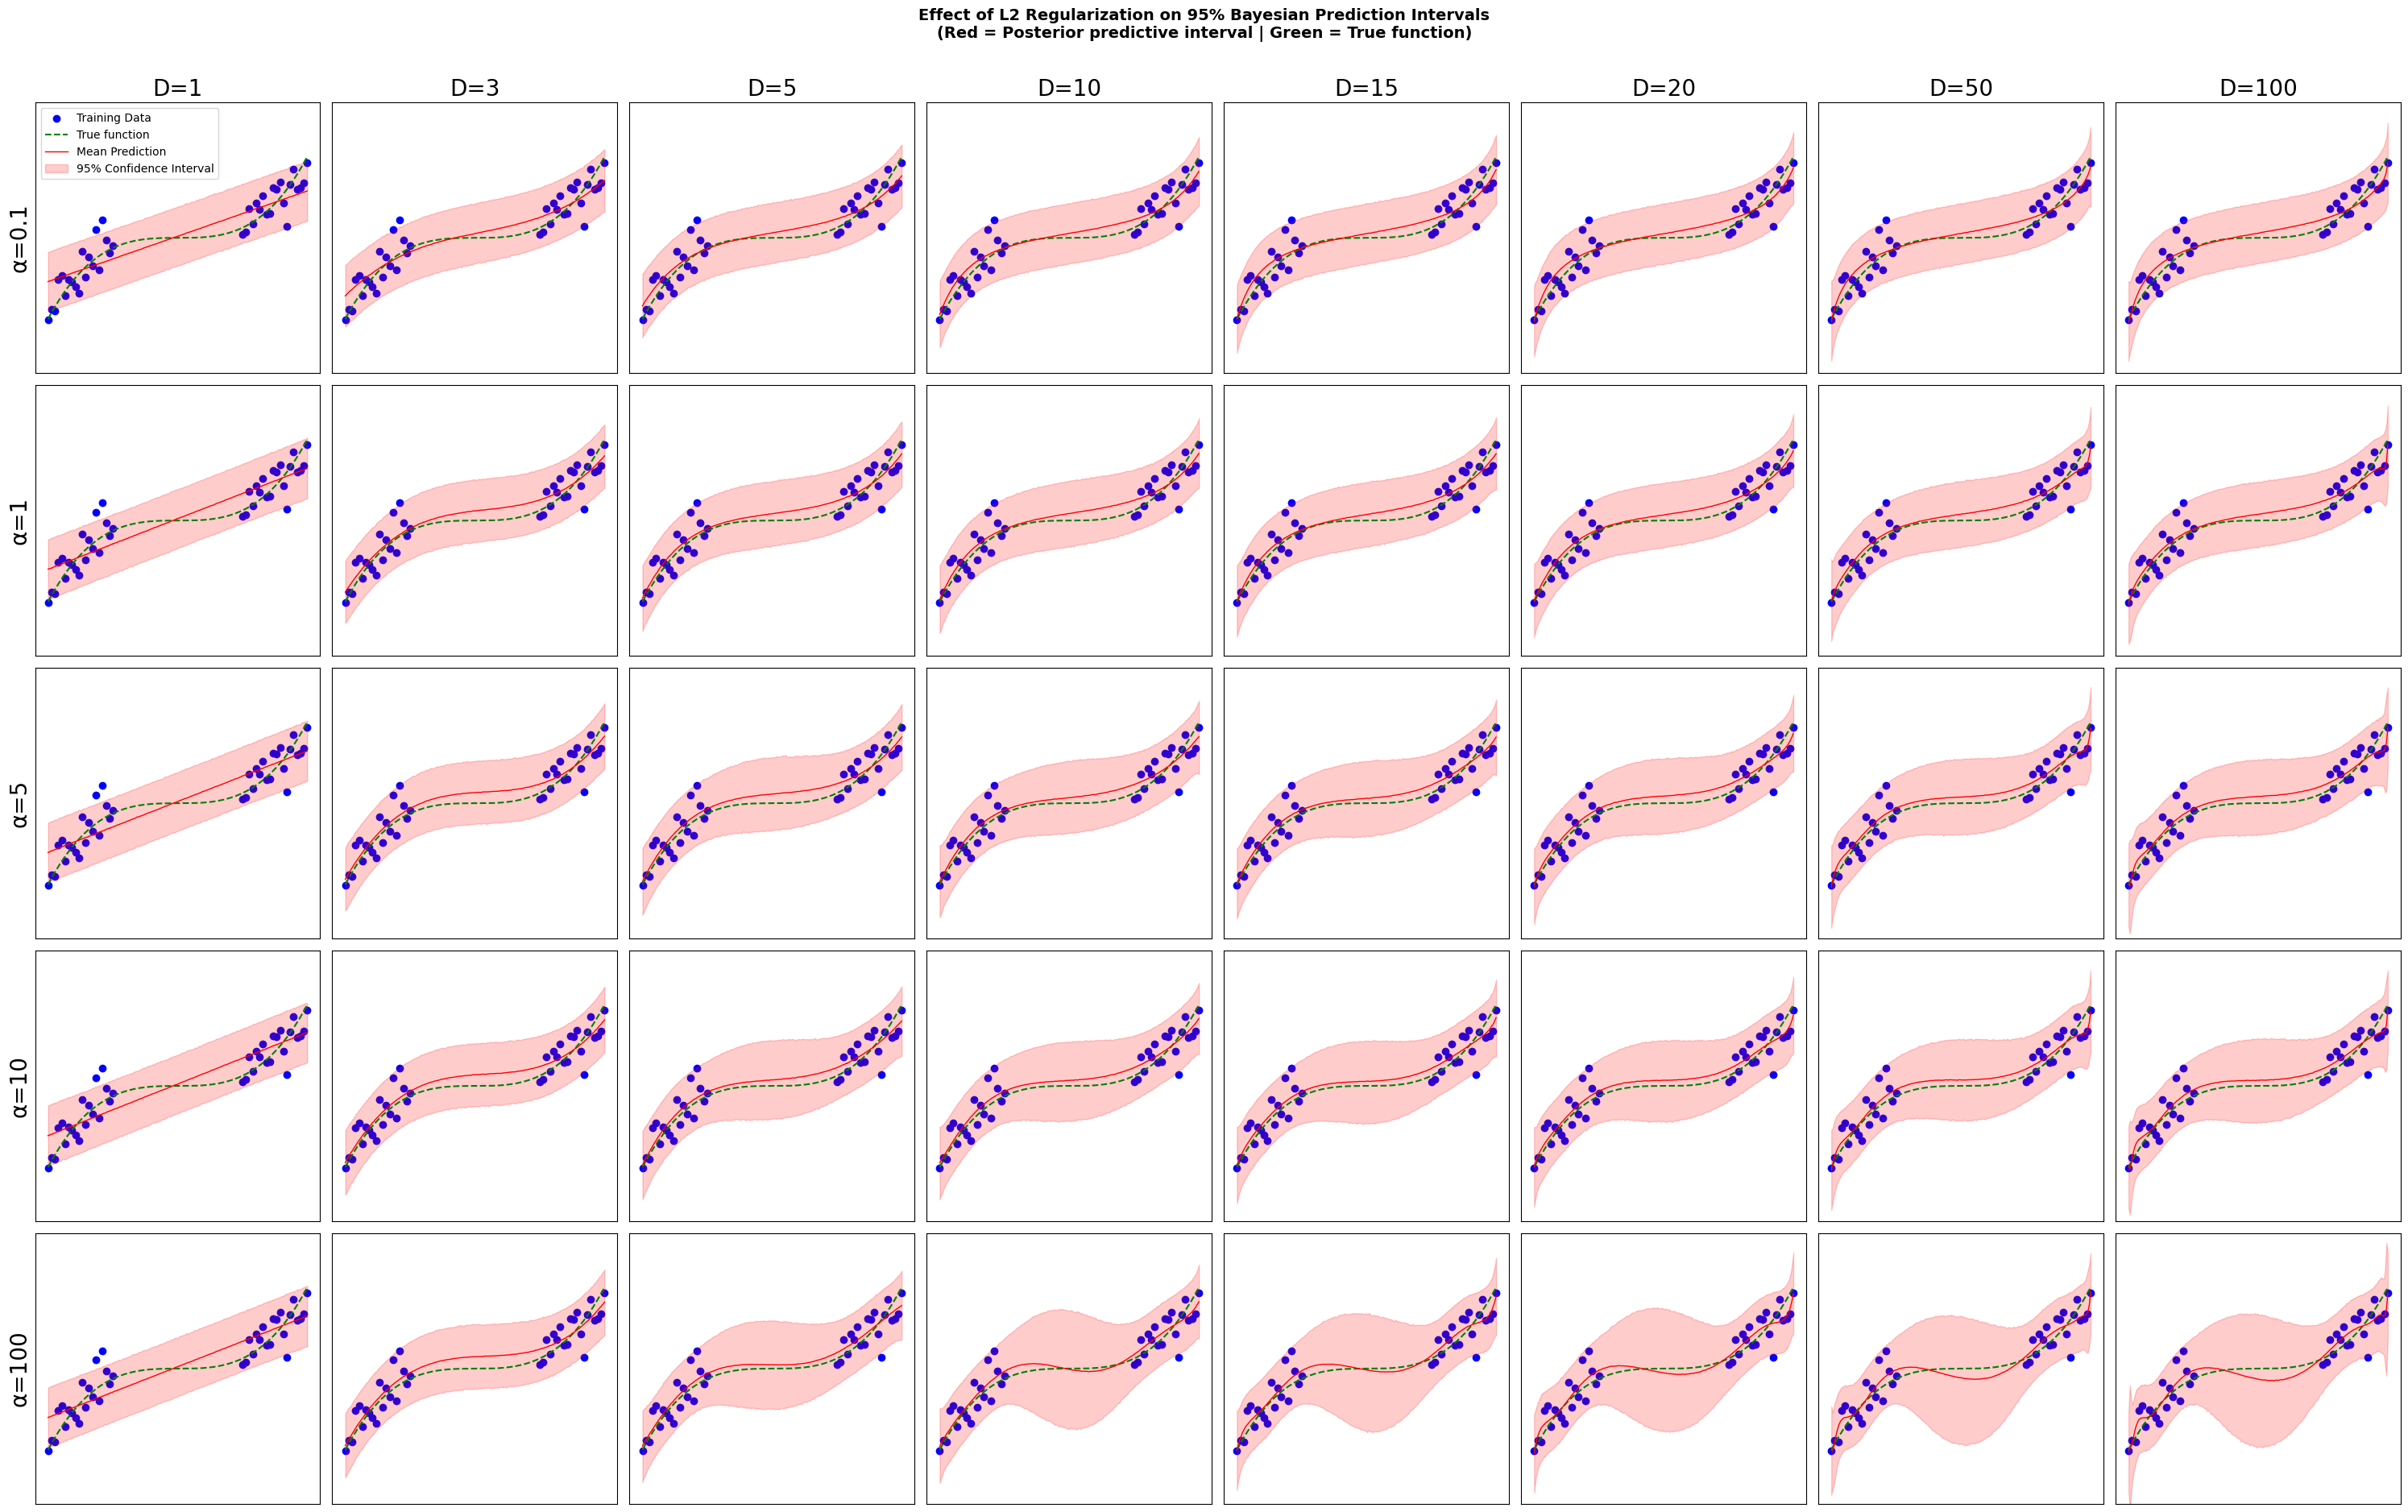

In [48]:
D = [1, 3, 5, 10, 15, 20, 50, 100]
alpha = [0.1, 1, 5, 10, 100]
number_of_points = 20

x_train, y_train, x_test = generate_data(number_of_points=number_of_points)
x_train = x_train[:, np.newaxis]
x_test = x_test[:, np.newaxis]
fig, axes = plt.subplots(len(alpha), len(D), figsize=(30, 18))
for row, a in enumerate(alpha):
    for col, d in enumerate(D):
        #create polynomial features
        poly = PolynomialFeatures(degree=d)
        x_train_poly = poly.fit_transform(x_train)
        x_test_poly = poly.transform(x_test)
        
        #get posterior predictive samples
        _, posterior_predictive_samples = get_posterior_samples(prior_var=a, noise_var=0.3, x_matrix=x_train_poly, y_matrix=y_train, x_test_matrix=x_test_poly, samples=200)
        
        #compute mean and 95% predictive interval
        mean_pred = np.mean(posterior_predictive_samples, axis=0)
        lower = np.percentile(posterior_predictive_samples, 2.5, axis=0)
        upper = np.percentile(posterior_predictive_samples, 97.5, axis=0)
        
        ax = axes[row, col]
        ax.scatter(x_train, y_train, color='blue', label='Training Data')
        ax.plot(x_test, 3 * x_test**3, 'g--', label='True function')
        ax.plot(x_test, mean_pred, color='red', label='Mean Prediction', linewidth=1)
        ax.fill_between(x_test.flatten(), lower, upper, color='red', alpha=0.2, label='95% Confidence Interval')
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        if row == 0:
            ax.set_title(f'D={d}', fontsize=20)
        if col == 0:
            ax.set_ylabel(f'α={a}', fontsize=20)
            
        if row == 0 and col == 0:
            ax.legend()
                
        ax.set_xticks([])
        ax.set_yticks([])
        
plt.tight_layout()
plt.suptitle('Effect of L2 Regularization on 95% Bayesian Prediction Intervals\n(Red = Posterior predictive interval | Green = True function)', y=1.04, fontsize=14, fontweight='bold')
plt.show()

Computing log-likelihoods...
Log-likelihood range: [-35.95, -26.41]


C:\Users\loicb\AppData\Local\Temp\ipykernel_10096\2234078781.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn')  # Red (bad) -> Yellow -> Green (good)
C:\Users\loicb\AppData\Local\Temp\ipykernel_10096\2234078781.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.96])


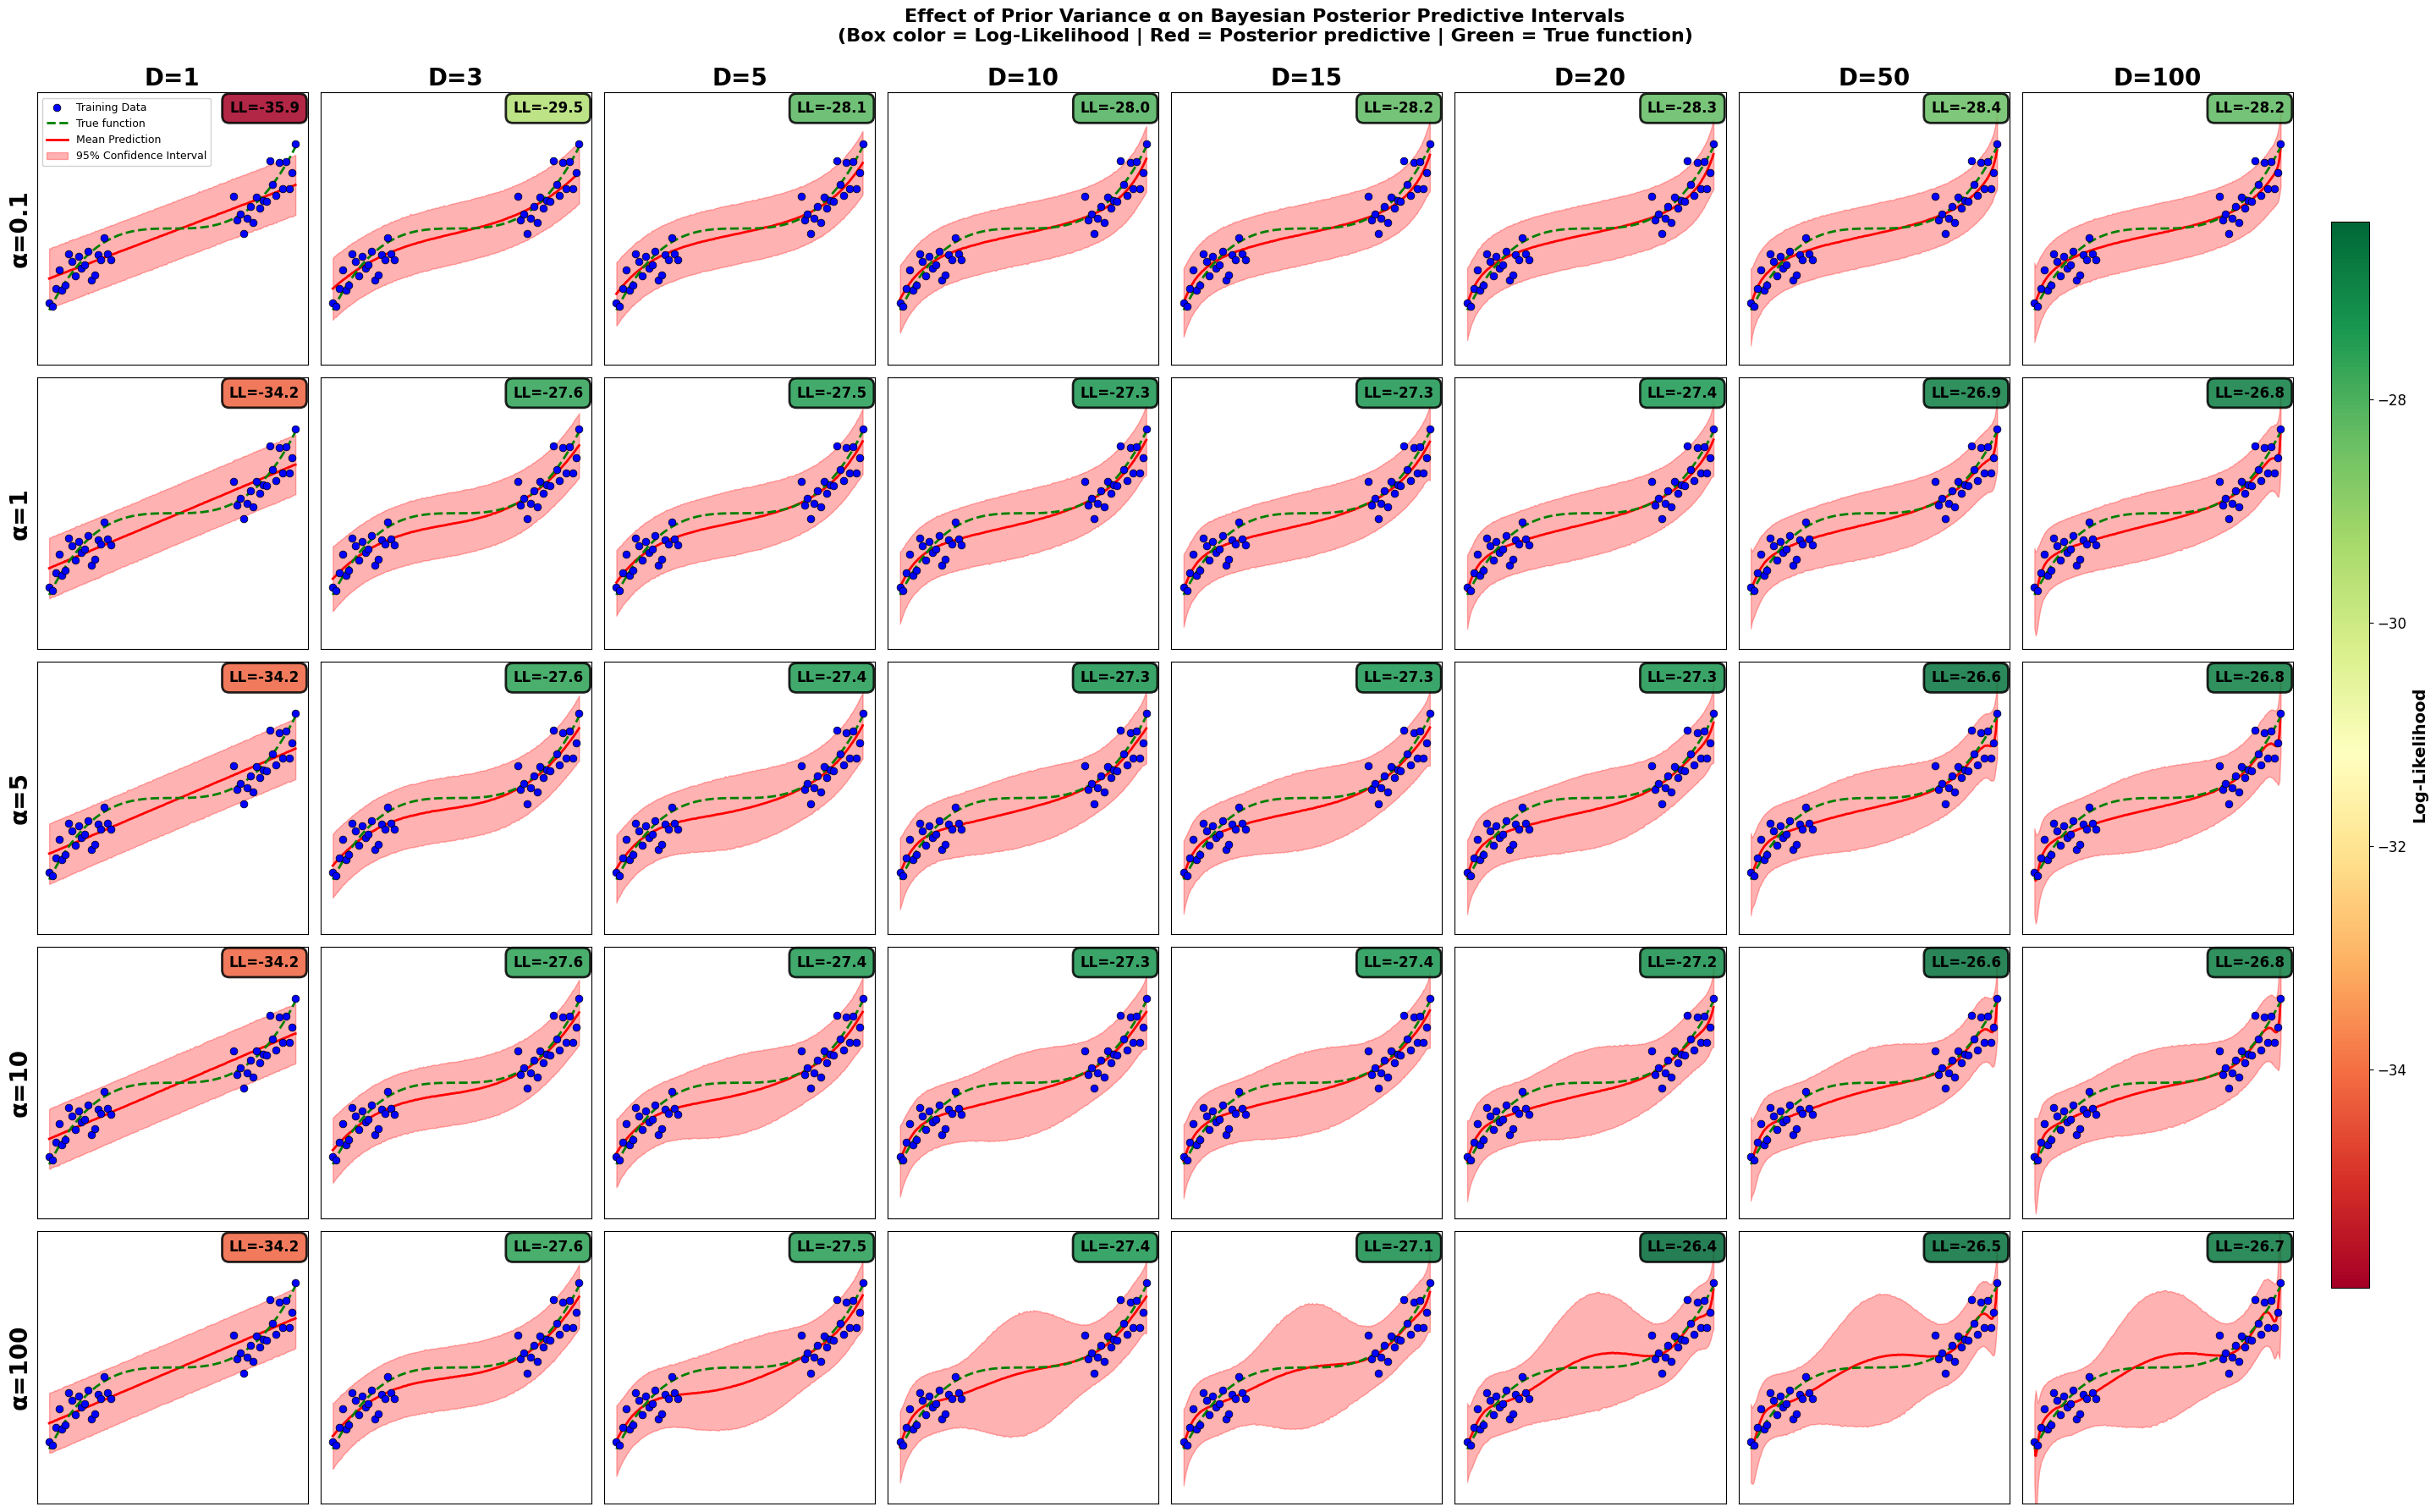


LOG-LIKELIHOOD ANALYSIS

Best model (highest LL): α=100, D=20, LL=-26.41
Worst model (lowest LL): α=0.1, D=1, LL=-35.95

Log-likelihood by degree (averaged over α):
  D=  1:  -34.55
  D=  3:  -27.97
  D=  5:  -27.60
  D= 10:  -27.47
  D= 15:  -27.47
  D= 20:  -27.31
  D= 50:  -27.01
  D=100:  -27.09

Log-likelihood by prior variance (averaged over D):
  α=  0.1:  -29.34
  α=  1.0:  -28.12
  α=  5.0:  -28.08
  α= 10.0:  -28.07
  α=100.0:  -27.93


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from sklearn.preprocessing import PolynomialFeatures
from scipy.stats import norm

def compute_log_likelihood(x_train_poly, y_train, mu_N, Sigma_N, noise_var):
    """
    Compute log-likelihood of training data under posterior predictive distribution.
    
    For each training point (x_m, y_m):
    p(y_m | x_m, Data) = N(μ_N^T x_m, σ² + x_m^T Σ_N x_m)
    
    Returns:
        log_likelihood: sum of log probabilities
    """
    log_likelihood = 0.0
    
    for i in range(len(y_train)):
        x_m = x_train_poly[i]
        y_m = y_train[i]
        
        # Posterior predictive mean: μ_N^T x_m
        pred_mean = mu_N.T @ x_m
        
        # Posterior predictive variance: σ² + x_m^T Σ_N x_m
        pred_var = noise_var + x_m.T @ Sigma_N @ x_m
        pred_std = np.sqrt(pred_var)
        
        # Log probability under Gaussian
        log_prob = norm.logpdf(y_m, loc=pred_mean, scale=pred_std)
        log_likelihood += log_prob
    
    return log_likelihood

# Parameters
D = [1, 3, 5, 10, 15, 20, 50, 100]
alpha = [0.1, 1, 5, 10, 100]
number_of_points = 20
noise_var = 0.3

# Generate data once
np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=number_of_points, noise_variance=noise_var)
x_train = x_train[:, np.newaxis]
x_test = x_test[:, np.newaxis]

# Storage for log-likelihoods (to compute global colormap)
log_likelihoods = np.zeros((len(alpha), len(D)))

# First pass: compute all log-likelihoods
print("Computing log-likelihoods...")
for row, a in enumerate(alpha):
    for col, d in enumerate(D):
        # Create polynomial features
        poly = PolynomialFeatures(degree=d, include_bias=True)
        x_train_poly = poly.fit_transform(x_train)
        
        # Prior: w ~ N(0, α*I)
        prior_cov = a * np.eye(x_train_poly.shape[1])
        
        # Posterior: N(μ_N, Σ_N)
        precision_prior = np.linalg.inv(prior_cov)
        precision_likelihood = (1 / noise_var) * (x_train_poly.T @ x_train_poly)
        
        Sigma_N = np.linalg.inv(precision_prior + precision_likelihood)
        mu_N = (1 / noise_var) * Sigma_N @ x_train_poly.T @ y_train
        
        # Compute log-likelihood
        ll = compute_log_likelihood(x_train_poly, y_train, mu_N, Sigma_N, noise_var)
        log_likelihoods[row, col] = ll

print(f"Log-likelihood range: [{log_likelihoods.min():.2f}, {log_likelihoods.max():.2f}]")

# Create colormap normalization
norm = Normalize(vmin=log_likelihoods.min(), vmax=log_likelihoods.max())
cmap = cm.get_cmap('RdYlGn')  # Red (bad) -> Yellow -> Green (good)

# Second pass: create visualization
fig, axes = plt.subplots(len(alpha), len(D), figsize=(30, 18))

for row, a in enumerate(alpha):
    for col, d in enumerate(D):
        # Create polynomial features
        poly = PolynomialFeatures(degree=d, include_bias=True)
        x_train_poly = poly.fit_transform(x_train)
        x_test_poly = poly.transform(x_test)
        
        # Get posterior predictive samples
        _, posterior_predictive_samples = get_posterior_samples(
            prior_var=a, 
            noise_var=noise_var, 
            x_matrix=x_train_poly, 
            y_matrix=y_train, 
            x_test_matrix=x_test_poly, 
            samples=200
        )
        
        # Compute mean and 95% predictive interval
        mean_pred = np.mean(posterior_predictive_samples, axis=0)
        lower = np.percentile(posterior_predictive_samples, 2.5, axis=0)
        upper = np.percentile(posterior_predictive_samples, 97.5, axis=0)
        
        # Get log-likelihood for this configuration
        ll = log_likelihoods[row, col]
        
        # Setup subplot
        ax = axes[row, col]
        
        # Plot elements
        ax.scatter(x_train, y_train, color='blue', s=40, label='Training Data', zorder=5, edgecolors='black', linewidths=0.5)
        ax.plot(x_test, 3 * x_test**3, 'g--', label='True function', linewidth=2, zorder=4)
        ax.plot(x_test, mean_pred, color='red', label='Mean Prediction', linewidth=2, zorder=3)
        ax.fill_between(x_test.flatten(), lower, upper, color='red', alpha=0.3, label='95% Confidence Interval', zorder=2)
        
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        # Add log-likelihood text box with colored background
        textstr = f'LL={ll:.1f}'
        
        # Get color from colormap based on log-likelihood
        box_color = cmap(norm(ll))
        
        # Create text box with gradient color
        props = dict(
            boxstyle='round,pad=0.5', 
            facecolor=box_color,  # Color based on LL value
            alpha=0.85,  # Slightly transparent
            edgecolor='black', 
            linewidth=2
        )
        
        ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='right', 
                bbox=props, fontweight='bold', color='black')
        
        # Titles and labels
        if row == 0:
            ax.set_title(f'D={d}', fontsize=20, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'α={a}', fontsize=20, fontweight='bold')
            
        if row == 0 and col == 0:
            ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
                
        ax.set_xticks([])
        ax.set_yticks([])

# Add colorbar to show log-likelihood scale
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.set_label('Log-Likelihood', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(rect=[0, 0, 0.91, 0.96])
plt.suptitle('Effect of Prior Variance α on Bayesian Posterior Predictive Intervals\n(Box color = Log-Likelihood | Red = Posterior predictive | Green = True function)', 
             y=0.99, fontsize=16, fontweight='bold')
plt.show()

# Print statistics
print("\n" + "="*80)
print("LOG-LIKELIHOOD ANALYSIS")
print("="*80)
print(f"\nBest model (highest LL): α={alpha[np.unravel_index(log_likelihoods.argmax(), log_likelihoods.shape)[0]]}, D={D[np.unravel_index(log_likelihoods.argmax(), log_likelihoods.shape)[1]]}, LL={log_likelihoods.max():.2f}")
print(f"Worst model (lowest LL): α={alpha[np.unravel_index(log_likelihoods.argmin(), log_likelihoods.shape)[0]]}, D={D[np.unravel_index(log_likelihoods.argmin(), log_likelihoods.shape)[1]]}, LL={log_likelihoods.min():.2f}")

print("\nLog-likelihood by degree (averaged over α):")
for col, d in enumerate(D):
    avg_ll = log_likelihoods[:, col].mean()
    print(f"  D={d:3d}: {avg_ll:7.2f}")

print("\nLog-likelihood by prior variance (averaged over D):")
for row, a in enumerate(alpha):
    avg_ll = log_likelihoods[row, :].mean()
    print(f"  α={a:5.1f}: {avg_ll:7.2f}")

Based on your visualizaion, describe in intuitive terms what is the role of $\alpha$ and $D$ in determining the shape of the posterior predictive uncertainty.
<br><br>
***Hint:*** Read Problem 3 before implementing Problem 2, you can implement both at the same time.
<br><br>
**Extra Credit:** When the feature map $\phi$ is a general (usually non-linear transformation), applying Bayesian linear regression on the transformed input is called **Bayesian Kernel Regression**. Choose your own non-linear feature map $\phi: \mathbb{R} \to \mathbb{R}^5$ and visualize the 95% posterior predictive interval of the Bayesian kernel regression for your choice of $\phi$ and $D = [1,3,5,10,15,20,50,100]$, $\alpha = [0.1, 1, 5, 10, 100]$. Compare the visualization to the that for Bayesian polynomial regression. Does the posterior predictive of your Bayesian kernel regression capture important properties of the posterior predictive of the Bayesian polynomial regression model?
<br><br>
**Note:** we highly recommend that you implement the following feature map:
<br><br>
\begin{align}
\phi: \mathbb{R}^{D'} &\to \mathbb{R}^D\\
\mathbf{x} &\mapsto \left[\sqrt{\frac{2}{D}} \cos(w_1^\top x + b_1), \ldots, \sqrt{\frac{2}{D}} \cos(w_D^\top x + b_D)\right]
\end{align}
<br>where $b_d \sim [0, 2\pi]$ and $w_d \sim N(0, \beta I_{D'\times D'})$ need to be randomly sampled and fixed before modeling and inference. For this exercise, we suggest setting $\beta=10$. The features generated by $\phi$ are called **Random Fourier Features**. As the number of features $D$ tends to infinity, the resulting Bayesian kernel regression model tends to an important type of Bayesian (nonparametric) model called Gaussian Process model. We will revisit the connection between Bayesian kernel regression and Gaussian processes in the latter part of the course.

3. **(Model Evaluation and Uncertainty Estimation)** Remember that a direct visual comparision of the 95% predictive interval against the training data is impractical! Rather, to evaluate the fit of the Bayesian model on the observed data, we evaluate the marginal log-likelihood of the data under the posterior. Given a test set $\{(\mathbf{x}^*_m, \mathbf{y}^*_m)\}$, the log posterior predictive likelihood or, simply, the **log-likelihood** is computed as:
\begin{align}
\\ \log \prod_{m=1}^M p(\mathbf{y}^*_m | \mathbf{x}^*_m, \text{Data}) &= \sum_{m=1}^M \log p(\mathbf{y}^*_m | \mathbf{x}^*_m, \text{Data})\\
&= \sum_{m=1}^M \log \int_\mathbf{w} p(\mathbf{y}^*_m | \mathbf{x}^*_m, \mathbf{w}) p(\mathbf{w}| \text{Data}) d\mathbf{w}
\end{align}
<br>i.e. the log-likelihood at a single observation $(\mathbf{x}^*_m, \mathbf{y}^*_m)$ is the log of the likelihood of the observation ***averaged over all models in the posterior***.
<br><br>
For Bayesian linear regression, with posterior ${N}(\mu_N, \Sigma_N)$ we have that
$$
p(y^*_m | x^*_m, \text{Data}) = {N}(\mu^\top\mathbf{x}^*_m, \sigma^2 + (\mathbf{x}^*_m)^\top\Sigma_N\mathbf{x}^*_m)
$$
where $\sigma^2$ is the variance of the observation noise.
<br><br>
For each choice of $D$ and $\alpha$ in Problem 2, compute the log-likelihood of the training data. Examine a models with the higher log-likelihoods and a few with lower log-likelihoods, what is the relationship between log-likelihood and predictive uncertainty? In particular, does a higher log-likelihood indicate "better" predictive uncertainty?

2. **(Bayesian versus Frequentist Uncertainty)** Compare the types of predictive uncertainties that are generated by Bayesian models and ensembles. Characterize the advantages and disadvantages of bootstrap uncertainties from an ensemble. Describe an situation where it would be better to compute bootstrap uncertainties rather than posterior predictive uncertainties from a Bayesian model.

  ***Hint:*** For example, consider situations where the data is scarce versus situations where the data is abundant; consider situations where clinicians can provide guidance on model selection using domain expertise versus situations where we would not know how patterns in the data would extrapolate to new populations of patients.

  Characterize the advantages and disadvantages of posterior predictive uncertainties from a Bayesian model. Describe an application where it is better to use these uncertainties rather than bootstrap uncertainties from an ensemble.

3. **(Measuring Uncertainty)** From your experiments, are any of the model evaluation metrics consdiered in this assignment (MSE, log-likelihood) appropriate for evaluating the quality of predictive uncertainty far away from the training data, that is, if we are concerned about the performance of models under covariate shift should we use these metrics to perform model selection?

  Do our commonly used "best practices" of training machine learning models help or hamper our ability to train models with useful predictive uncertainties?

  What would be a good metric for measuring uncertainty? How would you define "good" uncertainty in the first place?

  ***Hint:*** Can you formulate a definition of "good" uncertainty without referencing a specific down-stream task?

## Part III: Calibration and Posterior Predictive Checks
You may use these helpers as-is. Do not modify unless necessary for debugging.


In [ ]:
def reliability_diagram(probs, y_true, n_bins=10, title=None):
    """Plot a reliability diagram using confidence bins (binary case)."""
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    conf = np.zeros(n_bins)
    acc = np.zeros(n_bins)
    counts = np.zeros(n_bins)

    for b in range(n_bins):
        mask = bin_ids == b
        counts[b] = mask.sum()
        if counts[b] > 0:
            conf[b] = probs[mask].mean()
            acc[b] = y_true[mask].mean()
        else:
            conf[b] = np.nan
            acc[b] = np.nan

    plt.figure()
    plt.plot([0, 1], [0, 1])
    plt.scatter(conf, acc)
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Empirical frequency')
    if title is not None:
        plt.title(title)
    plt.ylim(0, 1)
    plt.xlim(0, 1)
    plt.show()

    return conf, acc, counts


def ece_binary(probs, y_true, n_bins=10):
    """Expected Calibration Error (ECE) for binary classification."""
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return float(ece)


def brier_binary(probs, y_true):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    return float(np.mean((probs - y_true)**2))


def temperature_scale(logits, T):
    """Binary temperature scaling on logits."""
    logits = np.asarray(logits)
    return 1 / (1 + np.exp(-logits / T))



First we will train a probabilistic classifier,
evaluate NLL, Brier, ECE, and visualize calibration using a reliability diagram.

**Dataset:** We generate a synthetic binary classification dataset.

NLL (log loss): 0.547263724664062
Brier: 0.1837454543065389
ECE: 0.0354439096800017


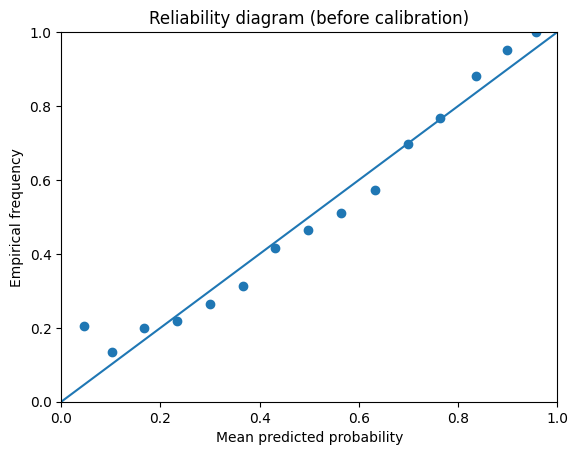

(array([0.04580185, 0.10314287, 0.16742143, 0.23347837, 0.30044462,
        0.36629914, 0.43026253, 0.49730675, 0.56474742, 0.63213458,
        0.6991298 , 0.76333738, 0.83636293, 0.8978497 , 0.95717013]),
 array([0.20454545, 0.13445378, 0.2       , 0.21938776, 0.265     ,
        0.31443299, 0.41463415, 0.46511628, 0.51075269, 0.57386364,
        0.6972973 , 0.76829268, 0.88198758, 0.95031056, 1.        ]),
 array([ 44., 119., 165., 196., 200., 194., 205., 172., 186., 176., 185.,
        164., 161., 161.,  72.]))

In [ ]:
X, y = make_classification(
    n_samples=8000,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    flip_y=0.02,
    class_sep=1.0,
    random_state=0,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_test)[:, 1]

print('NLL (log loss):', log_loss(y_test, probs))
print('Brier:', brier_binary(probs, y_test))
print('ECE:', ece_binary(probs, y_test, n_bins=15))

reliability_diagram(probs, y_test, n_bins=15, title='Reliability diagram (before calibration)')



1. In the reliability diagram above, is the model **overconfident**, **underconfident**, or close to calibrated?
2. Which metric among NLL, Brier, and ECE is *most directly* a calibration metric? Briefly justify.

Write your answer in the markdown cell below.


3. We will perform temperature scaling on a held-out calibration set.

**Steps**
Split X_train into a smaller train set and a calibration set. Fit the classifier on the smaller train set. Use the calibration set to choose a temperature T that minimizes NLL. Evaluate the reliability diagram, ECE, Brier, NLL on the test set before vs after scaling. What improved and what did not?

Best T: 0.9433732216299774


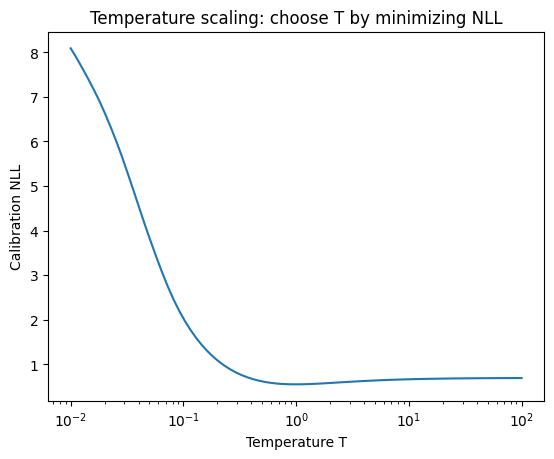

--- Test metrics ---
Before: NLL 0.5473960092006791 Brier 0.18385441500077168 ECE 0.03994141614140014
After : NLL 0.5475607231817698 Brier 0.18382349756511743 ECE 0.037917770147052325


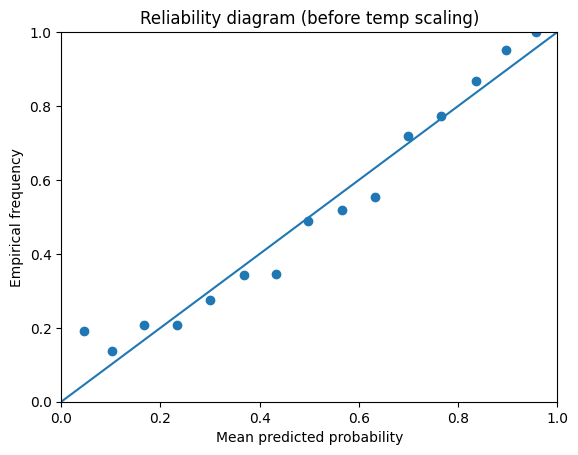

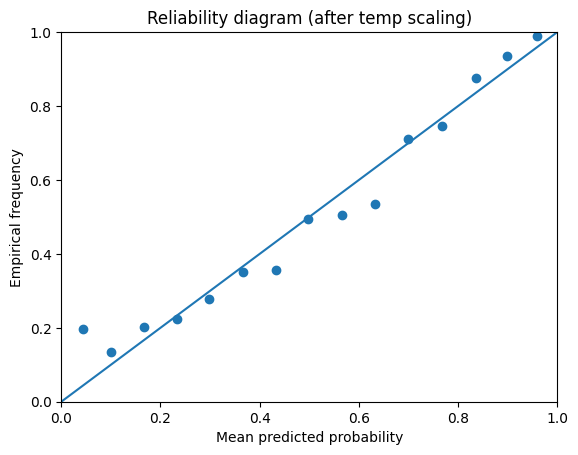

(array([0.04409992, 0.10053929, 0.16580705, 0.23258799, 0.29854342,
        0.36602708, 0.43248677, 0.49832624, 0.56498702, 0.63180947,
        0.69925629, 0.76718757, 0.83566957, 0.89846073, 0.95900905]),
 array([0.19642857, 0.13492063, 0.20231214, 0.22513089, 0.27807487,
        0.35051546, 0.35532995, 0.49382716, 0.5060241 , 0.53409091,
        0.70967742, 0.74556213, 0.875     , 0.93513514, 0.98863636]),
 array([ 56., 126., 173., 191., 187., 194., 197., 162., 166., 176., 186.,
        169., 144., 185.,  88.]))

In [ ]:
# Split train into (train_small, cal)
X_tr, X_cal, y_tr, y_cal = train_test_split(X_train, y_train, test_size=0.3, random_state=1, stratify=y_train)

clf2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
clf2.fit(X_tr, y_tr)

# Get logits for calibration and test
logits_cal = clf2.named_steps['lr'].decision_function(clf2.named_steps['scaler'].transform(X_cal))
logits_test = clf2.named_steps['lr'].decision_function(clf2.named_steps['scaler'].transform(X_test))

# Grid search for T
Ts = np.logspace(-2, 2, 80)
cal_nll = []
for T in Ts:
    p = temperature_scale(logits_cal, T)
    cal_nll.append(log_loss(y_cal, p))
cal_nll = np.array(cal_nll)

best_T = Ts[np.argmin(cal_nll)]
print('Best T:', best_T)

plt.figure()
plt.plot(Ts, cal_nll)
plt.xscale('log')
plt.xlabel('Temperature T')
plt.ylabel('Calibration NLL')
plt.title('Temperature scaling: choose T by minimizing NLL')
plt.show()

# Evaluate before/after on test
p_before = 1 / (1 + np.exp(-logits_test))
p_after = temperature_scale(logits_test, best_T)

print('--- Test metrics ---')
print('Before: NLL', log_loss(y_test, p_before), 'Brier', brier_binary(p_before, y_test), 'ECE', ece_binary(p_before, y_test, n_bins=15))
print('After : NLL', log_loss(y_test, p_after),  'Brier', brier_binary(p_after, y_test),  'ECE', ece_binary(p_after, y_test, n_bins=15))

reliability_diagram(p_before, y_test, n_bins=15, title='Reliability diagram (before temp scaling)')
reliability_diagram(p_after, y_test, n_bins=15, title='Reliability diagram (after temp scaling)')



### **Posterior Predictive Checks (PPCs) for regression**

We fit a simple probabilistic regression model and run PPC-style checks.

We assume Gaussian noise:
\[
Y \mid x \sim N(f(x), \sigma^2).
\]

We will:
- fit a ridge regression model for the mean function, and
- estimate \(\sigma\) on the training set,
then use this as a predictive distribution.

This is a simplified proxy to practice PPC mechanics.


In [ ]:
Xr, yr = make_regression(n_samples=4000, n_features=10, noise=15.0, random_state=0)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=0)

reg = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
reg.fit(Xr_train, yr_train)

mu_train = reg.predict(Xr_train)
mu_test = reg.predict(Xr_test)

# Estimate sigma from training residuals
resid = yr_train - mu_train
sigma_hat = np.std(resid)
print('Estimated sigma:', sigma_hat)


Estimated sigma: 14.72566424337125


4. Implement the average predictive negative log likelihood for a Gaussian predictive distribution: $ -\frac{1}{n}\sum_i \log N(y_i \mid \mu_i, \sigma^2). $ Return a scalar.

In [ ]:
import math

def gaussian_nll(y, mu, sigma):
    # TODO: implement average negative log likelihood for N(mu, sigma^2)
    raise NotImplementedError

# Uncomment after implementing
# print('Test NLL:', gaussian_nll(yr_test, mu_test, sigma_hat))


5. Perform a basic PPC: Simulate replicated outcomes $\tilde {y}^{(s)}\sim {N}(\mu_{test}, \sigma^2)$ for $S = 500$ replicates and compare statistics $T$ between replicated and observed outcomes. Use two statistics: $T_1$ = mean($y$); $T_2$ = variance($y$). Provide a plot showing the distribution of replicated $T_1$ and $T_2$ with the observed value marked and a short interpretation of whether the model appears to fit these statistics?

## Part IV: Conformal Prediction
We will implement split conformal prediction for regression.

Goal: produce prediction intervals $[L(x), U(x)]$ with approximate marginal coverage $(1-\alpha)$.

**Split conformal prediction for regression:**

i) Fit model on training set.

ii) On calibration set, compute residuals $r_i = |y_i - \hat{y}_i|$.

iii) Let $q$ be the $(1-\alpha)$-quantile of ${r_i}$.
Output interval for a new point $x$: $ [\hat{y}(x)-q,\ \hat{y}(x)+q]. $



In [ ]:
# Prepare data splits
Xr_tr, Xr_temp, yr_tr, yr_temp = train_test_split(Xr, yr, test_size=0.4, random_state=0)
Xr_cal, Xr_te, yr_cal, yr_te = train_test_split(Xr_temp, yr_temp, test_size=0.5, random_state=0)

base = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
base.fit(Xr_tr, yr_tr)

pred_cal = base.predict(Xr_cal)
pred_te = base.predict(Xr_te)

resid_cal = np.abs(yr_cal - pred_cal)

def split_conformal_interval(pred, resid_cal, alpha=0.1):
    # TODO: compute q = (1-alpha)-quantile of calibration residuals
    # Return lower, upper arrays for pred
    raise NotImplementedError

# Uncomment after implementing
# L, U = split_conformal_interval(pred_te, resid_cal, alpha=0.1)
# coverage = np.mean((yr_te >= L) & (yr_te <= U))
# avg_width = np.mean(U - L)
# print('Empirical coverage:', coverage)
# print('Average interval width:', avg_width)


1. After implementing `split_conformal_interval`:

i) Compute empirical coverage for $\alpha\in\{0.05, 0.1, 0.2\}$.

ii) Report average width for each $\alpha$.

iii) Briefly interpret the tradeoff.


2. In 5–8 sentences:

Under what assumptions does split conformal guarantee coverage?

Why might those assumptions fail under covariate shift?

What is the high-level idea behind weighted conformal methods?

Write your answer below.